<a href="https://colab.research.google.com/github/sanaabed41/smartnetenergy/blob/main/notebooks/5G_Final_EDA_complete__1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🔋 Prédiction de la Consommation Énergétique des Antennes 5G

**Contexte :** L'ITU (Union Internationale des Télécommunications) propose un benchmark pour modéliser
la consommation des stations de base 5G. L'objectif est d'aider les opérateurs à optimiser
leur consommation énergétique.

**Données :** 3 fichiers CSV issus d'un réseau réel → fusionnés en ~98 000 observations horaires.

**Pipeline global :**
```
Section 0 : Setup
Section 1 : EDA (Exploration)
Section 2 : Prétraitement & Merge
Section 3 : Feature Engineering
Section 4 : Stratégie de Split (G1 / G2 / G3)
Section 5 : Entraînement des modèles
Section 6 : Évaluation & Interprétabilité
Section 7 : Conclusion
```

**Équipe :** 3 membres — Coéquipier 1 (Sections 1–2) · Coéquipier 2 (Sections 3–4) · Coéquipier 3 (Sections 5–6)

---
## 🔧 Section 0 — Setup & Configuration globale

> Cette section est exécutée **une seule fois** au début.
> Elle centralise tous les imports, les chemins de fichiers et les paramètres globaux.
> Ainsi, si un chemin change, on le modifie ici et seulement ici.

### 0.1 — Imports

In [1]:
import sys
!{sys.executable} -m pip install catboost lightgbm shap azure-storage-file-datalake --quiet
print('Installation OK')

In [2]:
# Bibliothèques standard
import warnings
import os
import json
import pickle
from pathlib import Path
from dataclasses import dataclass, field
from typing import Dict, List, Optional, Tuple

# Manipulation de données
import numpy  as np
import pandas as pd

# Visualisation
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats

# Prétraitement & Métriques
from sklearn.preprocessing      import RobustScaler, LabelEncoder
from sklearn.model_selection     import (
    train_test_split,
    LeaveOneGroupOut,
    GroupShuffleSplit,
    KFold,
    cross_val_score,
    learning_curve,
    TimeSeriesSplit,
)
from sklearn.metrics             import mean_absolute_error, mean_squared_error, r2_score
from sklearn.base                import clone

# Modèles linéaires (baselines)
from sklearn.linear_model        import Ridge, Lasso

# Modèles ensemblistes
from sklearn.ensemble            import RandomForestRegressor, StackingRegressor
from lightgbm                    import LGBMRegressor
from catboost                    import CatBoostRegressor

# Interprétabilité
import shap

warnings.filterwarnings('ignore')

import torch
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device utilisé : {device}')

print('Imports OK')

Device utilisé : cpu
Imports OK


### 0.2 — Configuration globale

> **Bonne pratique :** tous les paramètres modifiables en un seul endroit.
> Si le chemin Drive change ou si on veut refaire tourner avec un autre seed,
> on ne touche qu'ici.

In [3]:
# Azure ML Studio — pas besoin de Google Drive
print('Azure ML Studio ready')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:
import os, io, tempfile, pickle
from pathlib import Path
from azure.storage.filedatalake import DataLakeServiceClient

SEED = 42
np.random.seed(SEED)

# ── Connexion Azure Data Lake ──
# La cle est stockee dans la variable d'environnement AZURE_STORAGE_KEY
# Configuree dans Azure ML Studio : Compute Instance -> Environment Variables
ACCOUNT_NAME = 'smartnetenergydl'
ACCOUNT_KEY  = os.environ['AZURE_STORAGE_KEY']
FILESYSTEM   = '5g-energy-data'

service = DataLakeServiceClient(
    account_url=f'https://{ACCOUNT_NAME}.dfs.core.windows.net',
    credential=ACCOUNT_KEY
)
fs_client = service.get_file_system_client(FILESYSTEM)

def read_csv_from_lake(path, **kwargs):
    data = fs_client.get_file_client(path).download_file().readall()
    return pd.read_csv(io.BytesIO(data), **kwargs)

def save_model_to_lake(model, filename):
    with tempfile.NamedTemporaryFile(suffix='.pkl', delete=False) as tmp:
        pickle.dump(model, tmp)
        tmp_path = tmp.name
    with open(tmp_path, 'rb') as f:
        fs_client.get_file_client(f'models/{filename}').upload_data(f.read(), overwrite=True)
    os.unlink(tmp_path)
    print(f'  Modele sauvegarde : models/{filename}')

def save_csv_to_lake(df, path):
    buf = io.BytesIO()
    df.to_csv(buf, index=False)
    buf.seek(0)
    fs_client.get_file_client(path).upload_data(buf.read(), overwrite=True)
    print(f'  CSV sauvegarde : {path}')

PATH_BSINFO = 'raw/BSinfo.csv'
PATH_CLDATA = 'raw/CLdata.csv'
PATH_ECDATA = 'raw/ECdata.csv'
MODEL_DIR   = 'models'

plt.rcParams['figure.dpi']       = 110
plt.rcParams['figure.facecolor'] = 'white'
sns.set_theme(style='whitegrid', palette='muted')

print('Configuration Azure OK')
print(f'   Seed      : {SEED}')
print(f'   Account   : {ACCOUNT_NAME}')
print(f'   Filesystem: {FILESYSTEM}')

Configuration OK
   Seed         : 42
   Données      : /content/drive/MyDrive/PFA/Data
   Modèles      : /content/drive/MyDrive/PFA/voltiq_models


### 0.3 — Chargement des données brutes

> On charge les 3 fichiers **séparément** et on vérifie immédiatement
> leurs dimensions et la période couverte.
>
> | Fichier | Contenu | Fréquence |
> |---------|---------|----------|
> | **BSinfo** | Caractéristiques hardware de chaque antenne (fixe) | 1 ligne / antenne |
> | **CLdata** | Charge réseau + modes d'économie d'énergie | 1 ligne / antenne / heure |
> | **ECdata** | Consommation mesurée en Watts → **notre cible** | 1 ligne / antenne / heure |

In [5]:
print('Chargement depuis Azure Data Lake...')
bs_data = read_csv_from_lake(PATH_BSINFO)
cl_data = read_csv_from_lake(PATH_CLDATA, parse_dates=['Time'])
ec_data = read_csv_from_lake(PATH_ECDATA, parse_dates=['Time'])

print('  DIMENSIONS DES 3 TABLES')
print('=' * 50)
for nom, df_tmp in [('BSinfo', bs_data), ('CLdata', cl_data), ('ECdata', ec_data)]:
    print(f'  {nom:8s} : {df_tmp.shape[0]:>7,} lignes x {df_tmp.shape[1]} colonnes')
print(f'  Periode : {cl_data["Time"].min().date()} -> {cl_data["Time"].max().date()}')
print(f'  Antennes: {bs_data["BS"].nunique()}')

  DIMENSIONS DES 3 TABLES
  BSinfo   :   1,217 lignes × 8 colonnes
  CLdata   : 125,575 lignes × 10 colonnes
  ECdata   :  92,629 lignes × 3 colonnes

  Période couverte : 2023-01-01  →  2023-01-08
  Antennes uniques : 1020
  Colonnes BSinfo  : ['BS', 'CellName', 'RUType', 'Mode', 'Frequency', 'Bandwidth', 'Antennas', 'TXpower']


---
## 🔍 Section 1 — EDA : Exploration des Données

> **Principe directeur :** chaque graphique pose une question précise.
> La réponse à cette question justifie une décision dans la suite du pipeline.
>
> **Sans EDA → on prend des décisions au hasard.**
>
> Plan de la section :
> - 1.1 Qualité des données (nulls, doublons)
> - 1.2 BSinfo — variabilité hardware des antennes
> - 1.3 Distribution de la cible Energy
> - 1.4 Patterns temporels (heure, jour de semaine)
> - 1.5 Distribution de la charge (load) et des ESModes
> - 1.6 Corrélations entre features et Energy
> - 1.7 Analyse par type d'antenne (RUType & Mode)
> - 1.8 ✅ Synthèse EDA → Décisions (bilan pour le jury)

### 1.0 _ Aperçu des données brutes

> **Première étape obligatoire** : regarder les données avant toute analyse.
> Répond à 3 questions : à quoi ressemblent les colonnes ? quels types ? quelles valeurs typiques ?

In [6]:
for nom, df_tmp in [('BSinfo', bs_data), ('CLdata', cl_data), ('ECdata', ec_data)]:
    print(f'  {nom}  —  {df_tmp.shape[0]:,} lignes × {df_tmp.shape[1]} colonnes')
    print(f'{'='*55}')
    display(df_tmp.head(3))
    print()


  BSinfo  —  1,217 lignes × 8 colonnes


,BS,CellName,RUType,Mode,Frequency,Bandwidth,Antennas,TXpower
0,B_0,Cell0,Type1,Mode2,365.0,20,4,6.875934
1,B_1,Cell0,Type2,Mode2,532.0,20,4,6.875934
2,B_2,Cell0,Type1,Mode2,365.0,20,4,6.875934



  CLdata  —  125,575 lignes × 10 colonnes


,Time,BS,CellName,load,ESMode1,ESMode2,ESMode3,ESMode4,ESMode5,ESMode6
0,2023-01-01 01:00:00,B_0,Cell0,0.487936,0.0,0.0,0.0,0,0.0,0.0
1,2023-01-01 02:00:00,B_0,Cell0,0.344468,0.0,0.0,0.0,0,0.0,0.0
2,2023-01-01 03:00:00,B_0,Cell0,0.193766,0.0,0.0,0.0,0,0.0,0.0



  ECdata  —  92,629 lignes × 3 colonnes


,Time,BS,Energy
0,2023-01-01 01:00:00,B_0,64.275037
1,2023-01-01 02:00:00,B_0,55.904335
2,2023-01-01 03:00:00,B_0,57.698057


In [7]:
# dtypes + describe() CLdata et ECdata
print('Types de colonnes :')
for nom, df_tmp in [('BSinfo', bs_data), ('CLdata', cl_data), ('ECdata', ec_data)]:
    print(f'\n── {nom}')
    for col, dtype in df_tmp.dtypes.items():
        print(f'   {col:<20} {str(dtype):<12}  {df_tmp[col].nunique():>6} valeurs uniques')

print('\n * describe() CLdata :')
display(cl_data.describe().round(3))
print('\n * describe() ECdata :')
display(ec_data.describe().round(3))


Types de colonnes :

── BSinfo
   BS                   object          1020 valeurs uniques
   CellName             object             4 valeurs uniques
   RUType               object            12 valeurs uniques
   Mode                 object             2 valeurs uniques
   Frequency            float64            9 valeurs uniques
   Bandwidth            int64              5 valeurs uniques
   Antennas             int64              6 valeurs uniques
   TXpower              float64           44 valeurs uniques

── CLdata
   Time                 datetime64[ns]     168 valeurs uniques
   BS                   object          1020 valeurs uniques
   CellName             object             4 valeurs uniques
   load                 float64        70505 valeurs uniques
   ESMode1              float64          565 valeurs uniques
   ESMode2              float64         1234 valeurs uniques
   ESMode3              float64          223 valeurs uniques
   ESMode4              int64            

,Time,load,ESMode1,ESMode2,ESMode3,ESMode4,ESMode5,ESMode6
count,125575,125575.000,125575.00,125575.000,125575.000,125575.0,125575.000,125575.000
mean,2023-01-03 22:42:31.291260160,0.239,0.04,0.037,0.000,0.0,0.000,0.039
min,2023-01-01 01:00:00,0.000,0.00,0.000,0.000,0.0,0.000,0.000
25%,2023-01-02 09:00:00,0.055,0.00,0.000,0.000,0.0,0.000,0.000
50%,2023-01-03 17:00:00,0.153,0.00,0.000,0.000,0.0,0.000,0.000
75%,2023-01-05 12:00:00,0.352,0.00,0.000,0.000,0.0,0.000,0.000
max,2023-01-08 00:00:00,0.994,1.00,1.000,0.155,0.0,0.768,0.931
std,NaN,0.236,0.19,0.182,0.002,0.0,0.003,0.165



 * describe() ECdata :


,Time,Energy
count,92629,92629.000
mean,2023-01-04 00:31:21.324423424,28.139
min,2023-01-01 01:00:00,0.747
25%,2023-01-02 11:00:00,18.236
50%,2023-01-03 20:00:00,24.066
75%,2023-01-05 14:00:00,35.725
max,2023-01-08 00:00:00,100.000
std,NaN,13.935


### 1.0b — Couverture temporelle & clés de jointure

> **Question clé :** Pourquoi ECdata (92 629 lignes) < CLdata (125 575 lignes) ?
> Cette analyse explique la perte de lignes lors du merge (Section 2).

In [8]:
# Couverture temporelle
print('* Couverture temporelle :')
for nom, df_tmp in [('CLdata', cl_data), ('ECdata', ec_data)]:
    h = df_tmp.groupby('BS', sort=False)['Time'].count()
    print(f'  {nom:<8} : {df_tmp.Time.min().date()} → {df_tmp.Time.max().date()}')
    print(f'           heures/antenne : médiane={h.median():.0f}  min={h.min()}  max={h.max()}')

# Clés de jointure
bs_cl = set(cl_data['BS']); bs_ec = set(ec_data['BS']); bs_bs = set(bs_data['BS'])
print(f'\n * Clés de jointure (BS) :')
print(f'  BS dans CLdata         : {len(bs_cl):,}')
print(f'  BS dans ECdata         : {len(bs_ec):,}')
print(f'  BS dans BSinfo         : {len(bs_bs):,}')
print(f'  BS communs CL ∩ EC     : {len(bs_cl & bs_ec):,}')
print(f'  BS dans CL mais pas EC : {len(bs_cl - bs_ec):,}')
print(f'\n => Inner join CL∩EC élimine les lignes sans mesure Energy.')
print('  Les capteurs hors-ligne expliquent la perte de 27 491 lignes.')


* Couverture temporelle :
  CLdata   : 2023-01-01 → 2023-01-08
           heures/antenne : médiane=139  min=24  max=330
  ECdata   : 2023-01-01 → 2023-01-08
           heures/antenne : médiane=110  min=1  max=130

 * Clés de jointure (BS) :
  BS dans CLdata         : 1,020
  BS dans ECdata         : 923
  BS dans BSinfo         : 1,020
  BS communs CL ∩ EC     : 923
  BS dans CL mais pas EC : 97

 => Inner join CL∩EC élimine les lignes sans mesure Energy.
  Les capteurs hors-ligne expliquent la perte de 27 491 lignes.


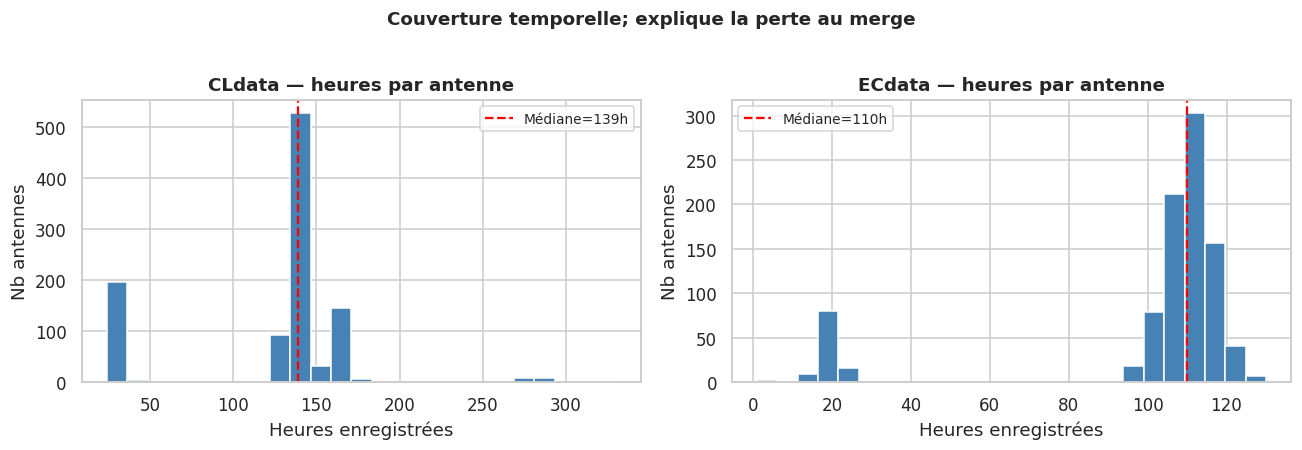

  CLdata sans Energy : 27,491 lignes (21.9%)
  Appariées (inner)  : 98,084 lignes => taille attendue du merge


In [9]:
# Distribution heures/antenne + gaps
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, (nom, df_tmp) in zip(axes, [('CLdata', cl_data), ('ECdata', ec_data)]):
    h = df_tmp.groupby('BS', sort=False)['Time'].count()
    ax.hist(h.values, bins=25, color='steelblue', edgecolor='white', lw=0.5)
    ax.axvline(h.median(), color='red', linestyle='--', label=f'Médiane={h.median():.0f}h')
    ax.set_title(f'{nom} — heures par antenne', fontweight='bold')
    ax.set_xlabel('Heures enregistrées'); ax.set_ylabel("Nb antennes"); ax.legend(fontsize=9)
plt.suptitle('Couverture temporelle; explique la perte au merge', fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout(); plt.show()

# Gaps : merge pandas rapide
cl_k = cl_data[['BS','Time']].copy()
ec_k = ec_data[['BS','Time']].copy()
inner = cl_k.merge(ec_k, on=['BS','Time'], how='inner')
print(f'  CLdata sans Energy : {len(cl_k)-len(inner):,} lignes ({(len(cl_k)-len(inner))/len(cl_k)*100:.1f}%)')
print(f'  Appariées (inner)  : {len(inner):,} lignes => taille attendue du merge')
del cl_k, ec_k, inner


### 1.1 — Qualité des données : valeurs manquantes & doublons

> **Question :** Les données sont-elles complètes et sans doublons ?
> Une valeur manquante dans une feature peut fausser le modèle.
> Un doublon peut gonfler artificiellement les métriques d'entraînement.

In [10]:
print('  QUALITÉ DES DONNÉES BRUTES')
print(f'{"Table":<10} {"Lignes":>8}  {"Nulls":>6}  {"Doublons":>10}')
print('-' * 55)

for nom, df_tmp in [('BSinfo', bs_data), ('CLdata', cl_data), ('ECdata', ec_data)]:
    nb_nulls    = df_tmp.isnull().sum().sum()
    nb_doublons = df_tmp.duplicated().sum()
    flag_null = '✅' if nb_nulls    == 0 else f'⚠️  {nb_nulls}'
    flag_dup  = '✅' if nb_doublons == 0 else f'⚠️  {nb_doublons}'
    print(f'{nom:<10} {df_tmp.shape[0]:>8,}  {flag_null:>6}  {flag_dup:>10}')

print()
print('→ Aucune valeur manquante et aucun doublon détectés.')
print('  Aucune correction nécessaire à cette étape.')

  QUALITÉ DES DONNÉES BRUTES
Table        Lignes   Nulls    Doublons
-------------------------------------------------------
BSinfo        1,217       ✅           ✅
CLdata      125,575       ✅           ✅
ECdata       92,629       ✅           ✅

→ Aucune valeur manquante et aucun doublon détectés.
  Aucune correction nécessaire à cette étape.


### 1.2 — BSinfo : variabilité hardware des antennes

> **Question :** Les antennes sont-elles toutes identiques, ou y a-t-il
> une grande variabilité de configuration ?
>
> Si une colonne a toujours la même valeur → elle n'apporte rien au modèle.
> Si elle varie beaucoup → elle sera une feature utile.

In [11]:
# ── Statistiques descriptives BSinfo ───────────────────────────────
print('=== Statistiques BSinfo (hardware des antennes) ===')
display(bs_data.describe().round(2))

=== Statistiques BSinfo (hardware des antennes) ===


,Frequency,Bandwidth,Antennas,TXpower
count,1217.00,1217.00,1217.00,1217.00
mean,408.41,12.71,3.91,6.92
std,158.54,7.40,9.12,0.46
min,155.60,2.00,1.00,5.38
25%,365.00,8.00,2.00,6.58
50%,426.98,10.00,2.00,6.88
75%,532.00,20.00,2.00,7.33
max,980.00,20.00,64.00,8.38


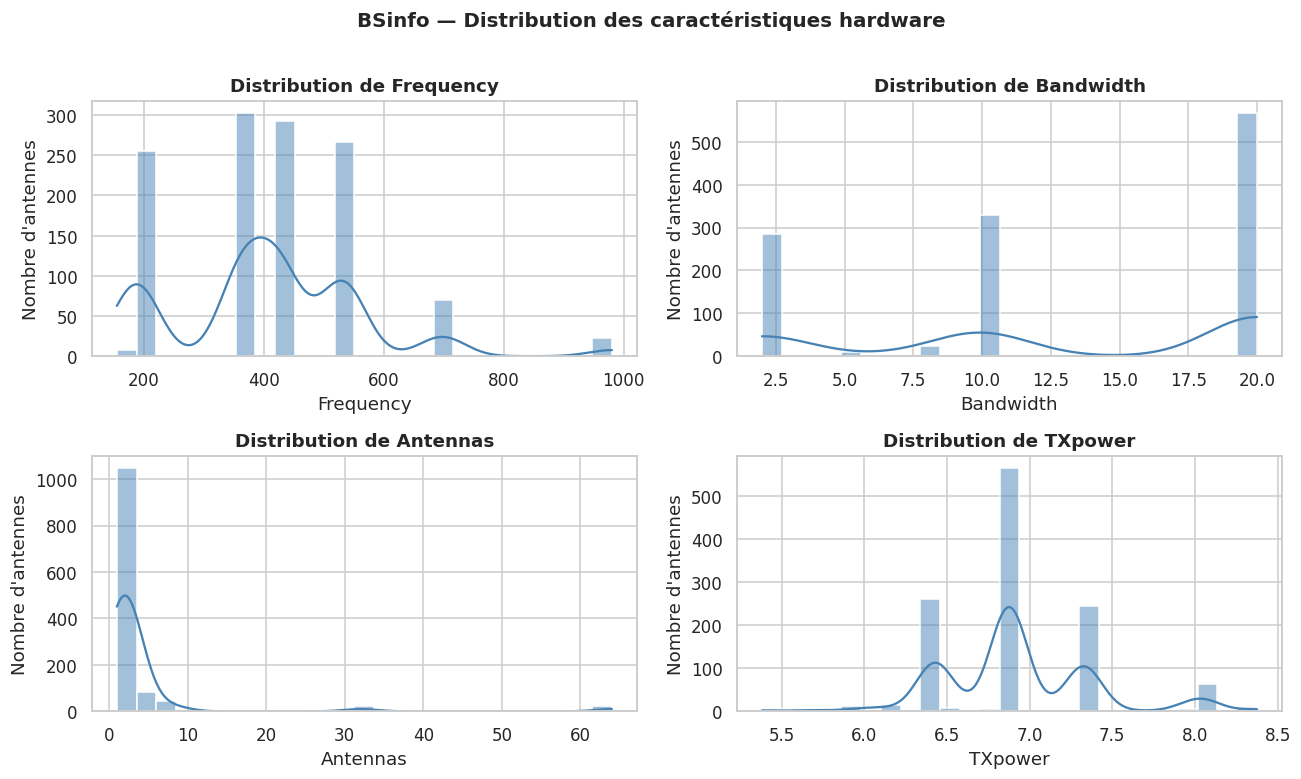


→ Observations :
  Frequency  : min=156 MHz, max=980 MHz — forte variabilité
  Antennas   : médiane=2, max=64 — distribution très asymétrique
  TXpower    : écart-type=0.46 — variabilité modérée
  Bandwidth  : valeurs discrètes ([np.int64(2), np.int64(5), np.int64(8), np.int64(10), np.int64(20)] MHz)


In [12]:
# ── Distributions des features numériques de BSinfo ─────────────────
cols_num_bs = ['Frequency', 'Bandwidth', 'Antennas', 'TXpower']

fig, axes = plt.subplots(2, 2, figsize=(12, 7))
axes = axes.flatten()

for i, col in enumerate(cols_num_bs):
    sns.histplot(bs_data[col], bins=25, kde=True, ax=axes[i], color='steelblue')
    axes[i].set_title(f'Distribution de {col}', fontweight='bold')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Nombre d\'antennes')

fig.suptitle('BSinfo — Distribution des caractéristiques hardware', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print('\n→ Observations :')
print(f'  Frequency  : min={bs_data.Frequency.min():.0f} MHz, max={bs_data.Frequency.max():.0f} MHz — forte variabilité')
print(f'  Antennas   : médiane={bs_data.Antennas.median():.0f}, max={bs_data.Antennas.max():.0f} — distribution très asymétrique')
print(f'  TXpower    : écart-type={bs_data.TXpower.std():.2f} — variabilité modérée')
print(f'  Bandwidth  : valeurs discrètes ({sorted(bs_data.Bandwidth.unique())} MHz)')

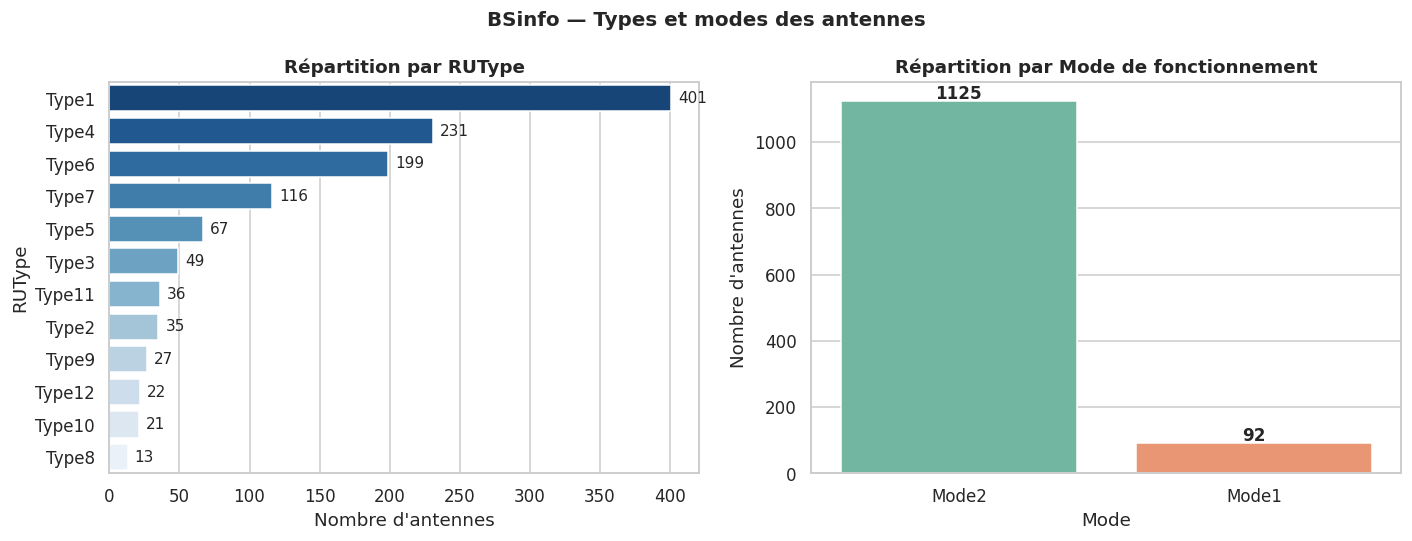


→ 12 types d'antennes (RUType) différents dans le réseau.
   Le RUType sera une feature importante car il influence directement la conso.


In [13]:
# ── Répartition des types d'antennes (RUType) et modes ──────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Countplot RUType
rutype_counts = bs_data['RUType'].value_counts()
sns.barplot(x=rutype_counts.values, y=rutype_counts.index, ax=axes[0],
            palette='Blues_r', orient='h')
axes[0].set_title('Répartition par RUType', fontweight='bold')
axes[0].set_xlabel('Nombre d\'antennes')
axes[0].set_ylabel('RUType')
for i, v in enumerate(rutype_counts.values):
    axes[0].text(v + 5, i, str(v), va='center', fontsize=10)

# Countplot Mode
mode_counts = bs_data['Mode'].value_counts()
sns.barplot(x=mode_counts.index, y=mode_counts.values, ax=axes[1],
            palette='Set2')
axes[1].set_title('Répartition par Mode de fonctionnement', fontweight='bold')
axes[1].set_xlabel('Mode')
axes[1].set_ylabel('Nombre d\'antennes')
for i, v in enumerate(mode_counts.values):
    axes[1].text(i, v + 5, str(v), ha='center', fontsize=11, fontweight='bold')

fig.suptitle('BSinfo — Types et modes des antennes', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'\n→ {bs_data["RUType"].nunique()} types d\'antennes (RUType) différents dans le réseau.')
print(f'   Le RUType sera une feature importante car il influence directement la conso.')

### 1.3 — Distribution de la cible : Energy (Watts)

> **Question :** La consommation est-elle distribuée normalement, ou asymétrique ?
>
> Cette observation détermine deux décisions clés :
> - **Si asymétrique** → on applique `log1p` sur la cible avant de modéliser
>   (les modèles convergent mieux sur des distributions proches du normal)
> - **Si outliers** → on les traite par capping (plafonnement) avant l'entraînement

In [14]:
energy = ec_data['Energy']

# ── Statistiques résumées ────────────────────────────────────────────
skewness = energy.skew()
kurtosis = energy.kurtosis()
Q1, Q3   = energy.quantile(0.25), energy.quantile(0.75)
IQR      = Q3 - Q1
borne_haute = Q3 + 3.0 * IQR
n_outliers  = (energy > borne_haute).sum()

print('=== Statistiques de la cible Energy (Watts) ===')
print(f'  Moyenne     : {energy.mean():.2f} W')
print(f'  Médiane     : {energy.median():.2f} W')
print(f'  Écart-type  : {energy.std():.2f} W')
print(f'  Min / Max   : {energy.min():.2f} W / {energy.max():.2f} W')
print(f'  Asymétrie   : {skewness:.3f}  {"→ distribution asymétrique à droite" if skewness > 0.5 else ""}')
print(f'  Kurtosis    : {kurtosis:.3f}')
print(f'  Outliers (3×IQR) : {n_outliers} valeurs au-dessus de {borne_haute:.1f} W')

=== Statistiques de la cible Energy (Watts) ===
  Moyenne     : 28.14 W
  Médiane     : 24.07 W
  Écart-type  : 13.93 W
  Min / Max   : 0.75 W / 100.00 W
  Asymétrie   : 1.087  → distribution asymétrique à droite
  Kurtosis    : 1.022
  Outliers (3×IQR) : 98 valeurs au-dessus de 88.2 W


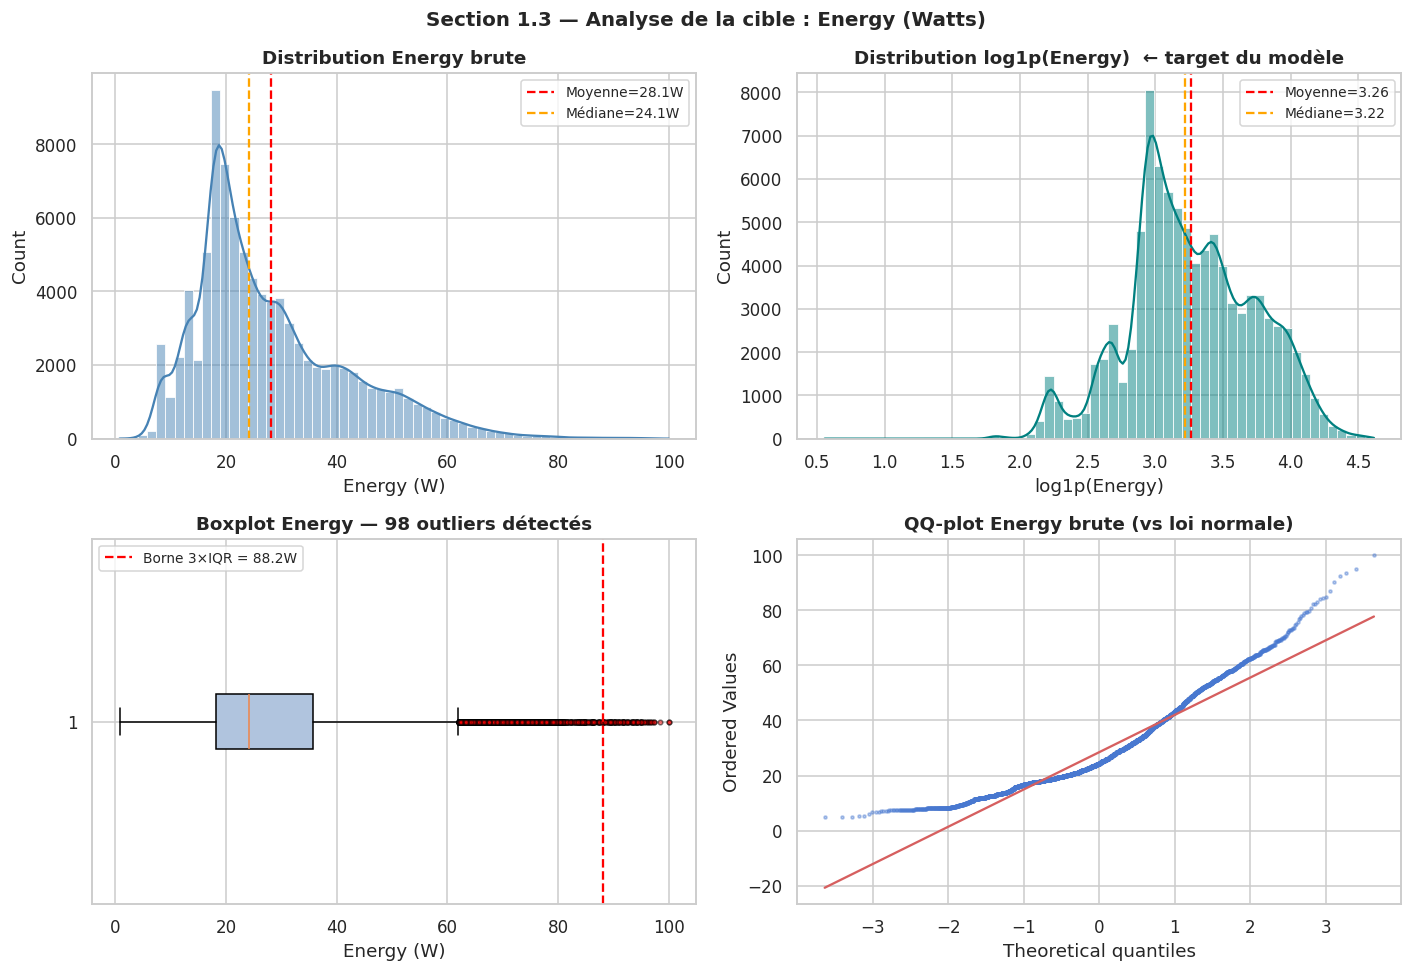


→ Décisions prises :
  1. La distribution est asymétrique (skew=1.09) → on utilisera log1p(Energy) comme target.
  2. 98 valeurs dépassent 3×IQR → on les cappera (plafonnera) en Section 2.
  3. Le QQ-plot confirme que la distribution s'éloigne de la normale aux extrêmes.


In [15]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))

# ── Histogramme Energy brute ─────────────────────────────────────────
sns.histplot(energy, bins=60, kde=True, ax=axes[0, 0], color='steelblue')
axes[0, 0].axvline(energy.mean(),   color='red',    linestyle='--', label=f'Moyenne={energy.mean():.1f}W')
axes[0, 0].axvline(energy.median(), color='orange', linestyle='--', label=f'Médiane={energy.median():.1f}W')
axes[0, 0].set_title('Distribution Energy brute', fontweight='bold')
axes[0, 0].set_xlabel('Energy (W)')
axes[0, 0].legend(fontsize=9)

# ── Histogramme log1p(Energy) ────────────────────────────────────────
log_energy = np.log1p(energy)
sns.histplot(log_energy, bins=60, kde=True, ax=axes[0, 1], color='teal')
axes[0, 1].axvline(log_energy.mean(),   color='red',    linestyle='--', label=f'Moyenne={log_energy.mean():.2f}')
axes[0, 1].axvline(log_energy.median(), color='orange', linestyle='--', label=f'Médiane={log_energy.median():.2f}')
axes[0, 1].set_title('Distribution log1p(Energy)  ← target du modèle', fontweight='bold')
axes[0, 1].set_xlabel('log1p(Energy)')
axes[0, 1].legend(fontsize=9)

# ── Boxplot avec outliers ────────────────────────────────────────────
axes[1, 0].boxplot(energy, vert=False, patch_artist=True,
                   boxprops=dict(facecolor='lightsteelblue'),
                   flierprops=dict(marker='o', markerfacecolor='red', markersize=3, alpha=0.5))
axes[1, 0].axvline(borne_haute, color='red', linestyle='--', label=f'Borne 3×IQR = {borne_haute:.1f}W')
axes[1, 0].set_title(f'Boxplot Energy — {n_outliers} outliers détectés', fontweight='bold')
axes[1, 0].set_xlabel('Energy (W)')
axes[1, 0].legend(fontsize=9)

# ── QQ-plot (test de normalité visuel) ───────────────────────────────
sample = energy.sample(min(5000, len(energy)), random_state=SEED)
stats.probplot(sample, dist='norm', plot=axes[1, 1])
axes[1, 1].set_title('QQ-plot Energy brute (vs loi normale)', fontweight='bold')
axes[1, 1].get_lines()[0].set(markersize=2, alpha=0.4)

fig.suptitle('Section 1.3 — Analyse de la cible : Energy (Watts)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('\n→ Décisions prises :')
print(f'  1. La distribution est asymétrique (skew={skewness:.2f}) → on utilisera log1p(Energy) comme target.')
print(f'  2. {n_outliers} valeurs dépassent 3×IQR → on les cappera (plafonnera) en Section 2.')
print('  3. Le QQ-plot confirme que la distribution s\'éloigne de la normale aux extrêmes.')

### 1.4 — Patterns temporels : heure & jour de semaine

> **Question :** La consommation varie-t-elle selon l'heure de la journée et le jour de la semaine ?
>
> Si oui → on créera des features cycliques `sin/cos` pour encoder
> ces patterns sans introduire de fausse distance entre 23h et 0h.

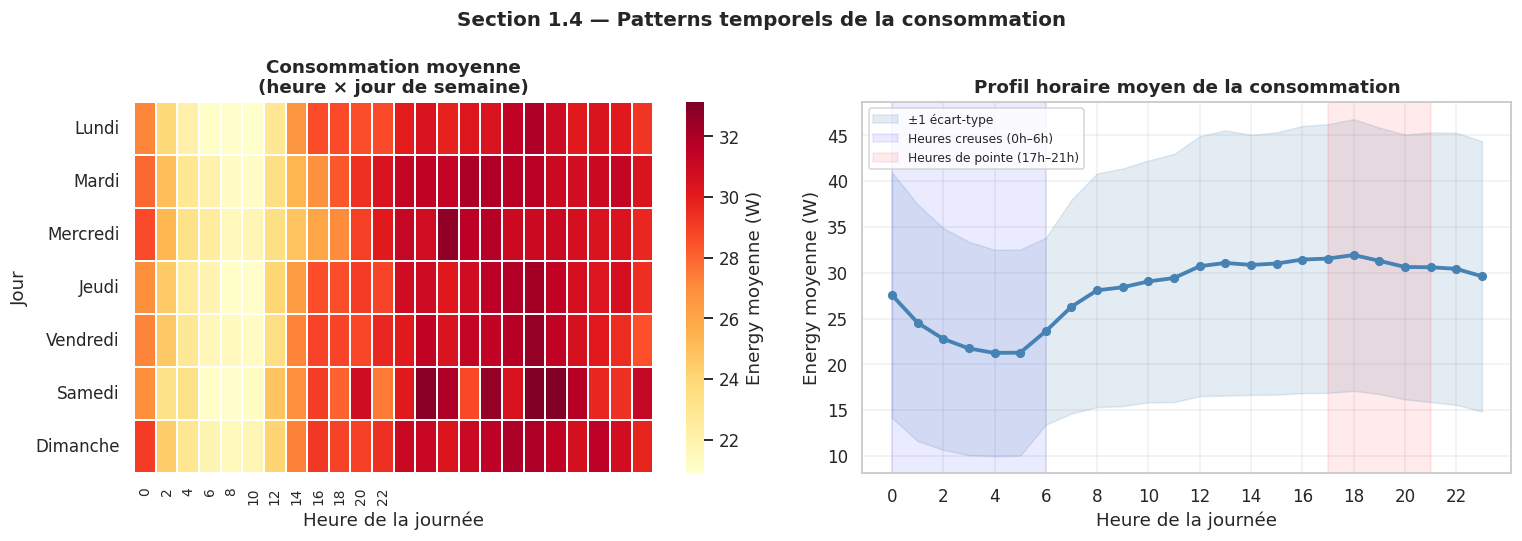


→ Observations clés :
  Pic de consommation   : 18h  (31.9 W en moyenne)
  Creux de consommation : 4h  (21.2 W en moyenne)
  Ratio pic/creux       : 1.50×

→ Décision : pattern horaire très marqué → features heure_sin, heure_cos, jour_sin, jour_cos
             + indicateurs binaires est_nuit (0h–6h) et est_pic (17h–21h)


In [16]:
# ── Préparer un DataFrame temporel (avant le merge complet) ──────────
# On joint ECdata et CLdata pour avoir Energy + Time dans la même table
df_temp = ec_data.copy()
df_temp['heure']    = df_temp['Time'].dt.hour
df_temp['jour_sem'] = df_temp['Time'].dt.dayofweek   # 0=Lundi, 6=Dimanche
df_temp['jour_nom'] = df_temp['Time'].dt.day_name()  # pour l'affichage

JOURS_FR = ['Lundi', 'Mardi', 'Mercredi', 'Jeudi', 'Vendredi', 'Samedi', 'Dimanche']

# ── Heatmap : consommation moyenne selon heure × jour ────────────────
pivot = df_temp.groupby(['jour_sem', 'heure'])['Energy'].mean().unstack()
pivot.index = JOURS_FR[:len(pivot)]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(pivot, ax=axes[0], cmap='YlOrRd', linewidths=0.3,
            cbar_kws={'label': 'Energy moyenne (W)'},
            xticklabels=range(0, 24, 2))
axes[0].set_title('Consommation moyenne\n(heure × jour de semaine)', fontweight='bold')
axes[0].set_xlabel('Heure de la journée')
axes[0].set_ylabel('Jour')
axes[0].tick_params(axis='x', labelsize=9)

# ── Profil horaire moyen ─────────────────────────────────────────────
profil_horaire = df_temp.groupby('heure')['Energy'].agg(['mean', 'std']).reset_index()
axes[1].plot(profil_horaire['heure'], profil_horaire['mean'],
             color='steelblue', lw=2.5, marker='o', markersize=5)
axes[1].fill_between(profil_horaire['heure'],
                     profil_horaire['mean'] - profil_horaire['std'],
                     profil_horaire['mean'] + profil_horaire['std'],
                     alpha=0.15, color='steelblue', label='±1 écart-type')
# Zones heures creuses / heures de pointe
axes[1].axvspan(0, 6,   alpha=0.08, color='blue',  label='Heures creuses (0h–6h)')
axes[1].axvspan(17, 21, alpha=0.08, color='red',   label='Heures de pointe (17h–21h)')
axes[1].set_title('Profil horaire moyen de la consommation', fontweight='bold')
axes[1].set_xlabel('Heure de la journée')
axes[1].set_ylabel('Energy moyenne (W)')
axes[1].set_xticks(range(0, 24, 2))
axes[1].legend(fontsize=8)
axes[1].grid(alpha=0.3)

fig.suptitle('Section 1.4 — Patterns temporels de la consommation', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# ── Résumé chiffré ────────────────────────────────────────────────────
heure_max = profil_horaire.loc[profil_horaire['mean'].idxmax(), 'heure']
heure_min = profil_horaire.loc[profil_horaire['mean'].idxmin(), 'heure']
print(f'\n→ Observations clés :')
print(f'  Pic de consommation   : {heure_max}h  ({profil_horaire["mean"].max():.1f} W en moyenne)')
print(f'  Creux de consommation : {heure_min}h  ({profil_horaire["mean"].min():.1f} W en moyenne)')
print(f'  Ratio pic/creux       : {profil_horaire["mean"].max() / profil_horaire["mean"].min():.2f}×')
print()
print('→ Décision : pattern horaire très marqué → features heure_sin, heure_cos, jour_sin, jour_cos')
print('             + indicateurs binaires est_nuit (0h–6h) et est_pic (17h–21h)')

### 1.5 — Distribution de la charge (load) et des ESModes

> **Question 1 :** Comment se distribue la charge réseau (`load`) ?
> Est-elle souvent nulle (antennes en veille) ou toujours active ?
>
> **Question 2 :** Les modes d'économie d'énergie (`ESMode1` à `ESMode6`) sont-ils
> tous utilisés ? Un mode jamais activé n'a aucune valeur prédictive.

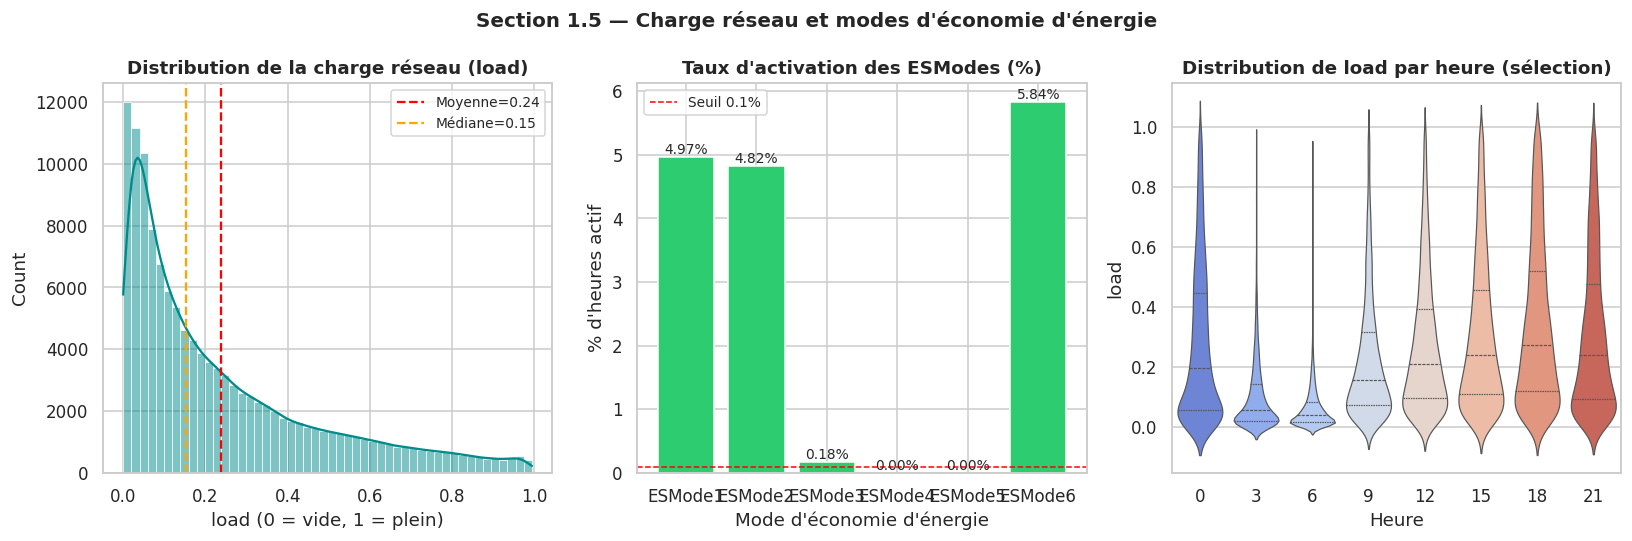


→ Taux d'activation des ESModes :
   ESMode1 : 4.97%  →  ✅ GARDÉ
   ESMode2 : 4.82%  →  ✅ GARDÉ
   ESMode3 : 0.18%  →  ✅ GARDÉ
   ESMode4 : 0.00%  →  ❌ À SUPPRIMER (trop rare)
   ESMode5 : 0.00%  →  ❌ À SUPPRIMER (trop rare)
   ESMode6 : 5.84%  →  ✅ GARDÉ

→ Décision : supprimer ['ESMode4', 'ESMode5'] (aucune valeur prédictive)


In [17]:
es_cols = [c for c in cl_data.columns if 'ESMode' in c]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# ── Histogramme load ─────────────────────────────────────────────────
sns.histplot(cl_data['load'], bins=50, kde=True, ax=axes[0], color='darkcyan')
axes[0].axvline(cl_data['load'].mean(),   color='red',    linestyle='--',
                label=f'Moyenne={cl_data["load"].mean():.2f}')
axes[0].axvline(cl_data['load'].median(), color='orange', linestyle='--',
                label=f'Médiane={cl_data["load"].median():.2f}')
axes[0].set_title('Distribution de la charge réseau (load)', fontweight='bold')
axes[0].set_xlabel('load (0 = vide, 1 = plein)')
axes[0].legend(fontsize=9)

# ── Taux d'activation de chaque ESMode ──────────────────────────────
taux_es = {col: (cl_data[col] > 0).mean() * 100 for col in es_cols}
colors_es = ['#2ecc71' if v > 0.1 else '#e74c3c' for v in taux_es.values()]
axes[1].bar(taux_es.keys(), taux_es.values(), color=colors_es, edgecolor='white')
axes[1].set_title('Taux d\'activation des ESModes (%)', fontweight='bold')
axes[1].set_xlabel('Mode d\'économie d\'énergie')
axes[1].set_ylabel('% d\'heures actif')
axes[1].axhline(0.1, color='red', linestyle='--', linewidth=1, label='Seuil 0.1%')
axes[1].legend(fontsize=9)
for i, (k, v) in enumerate(taux_es.items()):
    axes[1].text(i, v + 0.05, f'{v:.2f}%', ha='center', fontsize=9)

# ── Violinplot : load par heure ──────────────────────────────────────
# On prend un sous-ensemble pour ne pas surcharger le graphique
sample_cl = cl_data.copy()
sample_cl['heure'] = sample_cl['Time'].dt.hour
heures_selectionnees = [0, 3, 6, 9, 12, 15, 18, 21]
subset = sample_cl[sample_cl['heure'].isin(heures_selectionnees)]
sns.violinplot(data=subset, x='heure', y='load', ax=axes[2],
               palette='coolwarm', inner='quartile', linewidth=0.8)
axes[2].set_title('Distribution de load par heure (sélection)', fontweight='bold')
axes[2].set_xlabel('Heure')
axes[2].set_ylabel('load')

fig.suptitle('Section 1.5 — Charge réseau et modes d\'économie d\'énergie', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('\n→ Taux d\'activation des ESModes :')
for col, v in taux_es.items():
    statut = '✅ GARDÉ' if v > 0.1 else '❌ À SUPPRIMER (trop rare)'
    print(f'   {col} : {v:.2f}%  →  {statut}')

modes_a_suppr = [col for col, v in taux_es.items() if v <= 0.1]
print(f'\n→ Décision : supprimer {modes_a_suppr} (aucune valeur prédictive)')

### 1.6 — Corrélations : quelles features sont liées à Energy ?

> **Question :** Parmi toutes les colonnes disponibles, lesquelles sont
> le plus corrélées à la consommation ?
>
> On travaille ici sur un **merge partiel** (CLdata + ECdata + BSinfo)
> pour avoir toutes les features dans une seule table.
> C'est une pré-visualisation avant le merge officiel de la Section 2.

In [18]:
# ── Merge partiel pour l'EDA ─────────────────────────────────────────
# On garde la même logique que la Section 2 mais sans les transformations
cl_data['Time_str'] = cl_data['Time'].dt.strftime('%Y-%m-%d %H:%M:%S')
ec_data['Time_str'] = ec_data['Time'].dt.strftime('%Y-%m-%d %H:%M:%S')

df_eda = cl_data.merge(ec_data[['BS', 'Time_str', 'Energy']], on=['BS', 'Time_str'], how='inner')
df_eda = df_eda.merge(bs_data.drop_duplicates(subset='BS'), on='BS', how='left')

# Encoder RUType et Mode pour la corrélation
df_eda['RUType_enc'] = LabelEncoder().fit_transform(df_eda['RUType'])
df_eda['Mode_enc']   = LabelEncoder().fit_transform(df_eda['Mode'])

# Colonnes numériques pour la heatmap
cols_corr = ['load', 'ESMode1', 'ESMode2', 'ESMode3', 'ESMode6',
             'Frequency', 'Bandwidth', 'Antennas', 'TXpower',
             'RUType_enc', 'Mode_enc', 'Energy']
df_corr = df_eda[cols_corr].dropna()

print(f'DataFrame EDA : {df_corr.shape[0]:,} lignes × {df_corr.shape[1]} colonnes')

DataFrame EDA : 98,084 lignes × 12 colonnes


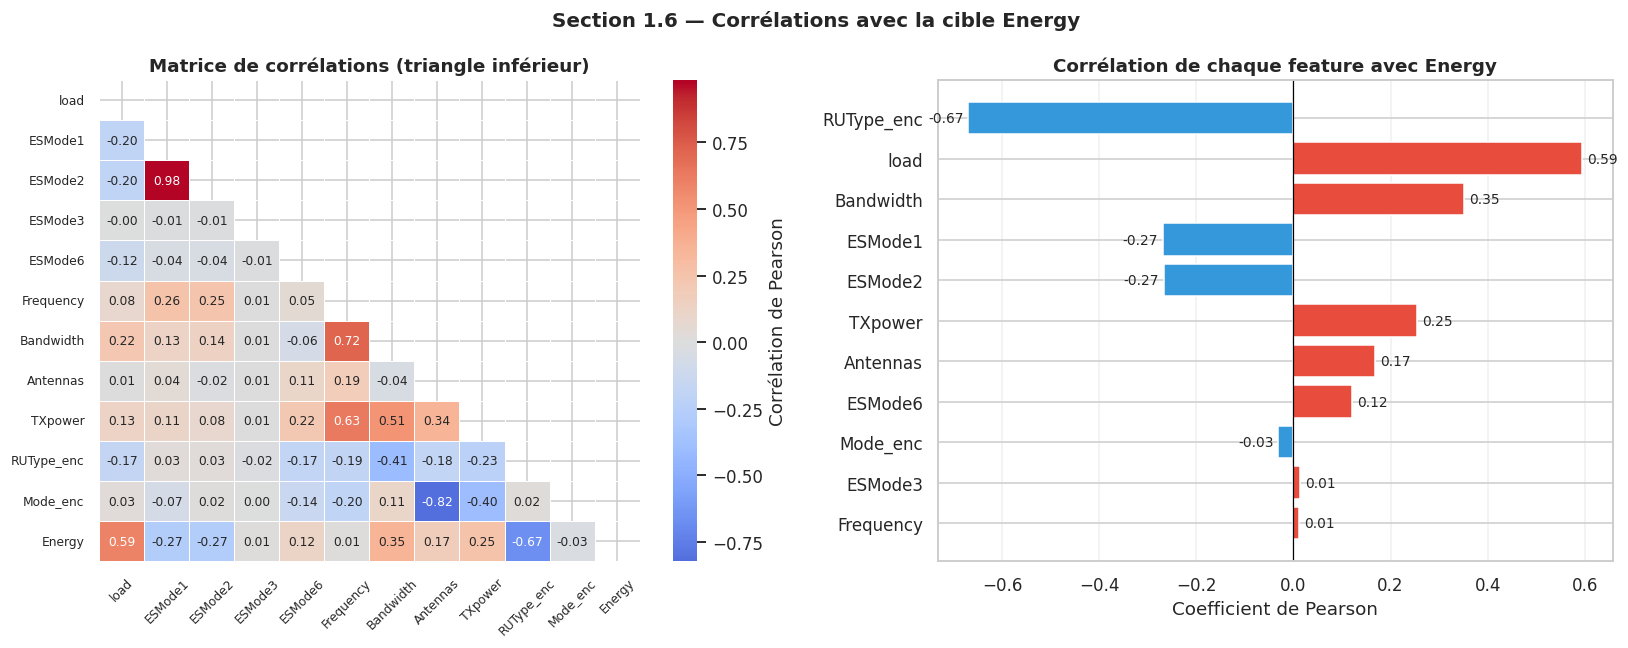


→ Top 3 features les plus corrélées avec Energy :
   RUType_enc      : r = -0.670
   load            : r = 0.595
   Bandwidth       : r = 0.351


In [19]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# ── Heatmap des corrélations ──────────────────────────────────────────
corr_matrix = df_corr.corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))  # masquer le triangle supérieur
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5, ax=axes[0],
            annot_kws={'size': 8}, cbar_kws={'label': 'Corrélation de Pearson'})
axes[0].set_title('Matrice de corrélations (triangle inférieur)', fontweight='bold')
axes[0].tick_params(axis='x', rotation=45, labelsize=8)
axes[0].tick_params(axis='y', labelsize=8)

# ── Bar chart : corrélation de chaque feature avec Energy ────────────
corr_energy = corr_matrix['Energy'].drop('Energy').sort_values(key=abs, ascending=True)
colors_bar  = ['#e74c3c' if v > 0 else '#3498db' for v in corr_energy]
axes[1].barh(corr_energy.index, corr_energy.values, color=colors_bar, edgecolor='white')
axes[1].axvline(0, color='black', linewidth=0.8)
axes[1].set_title('Corrélation de chaque feature avec Energy', fontweight='bold')
axes[1].set_xlabel('Coefficient de Pearson')
axes[1].grid(axis='x', alpha=0.3)
for i, (idx, v) in enumerate(corr_energy.items()):
    axes[1].text(v + (0.01 if v >= 0 else -0.01), i,
                 f'{v:.2f}', va='center', ha='left' if v >= 0 else 'right', fontsize=9)

fig.suptitle('Section 1.6 — Corrélations avec la cible Energy', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

top3 = corr_energy.abs().nlargest(3)
print('\n→ Top 3 features les plus corrélées avec Energy :')
for feat, val in top3.items():
    print(f'   {feat:15s} : r = {corr_energy[feat]:.3f}')

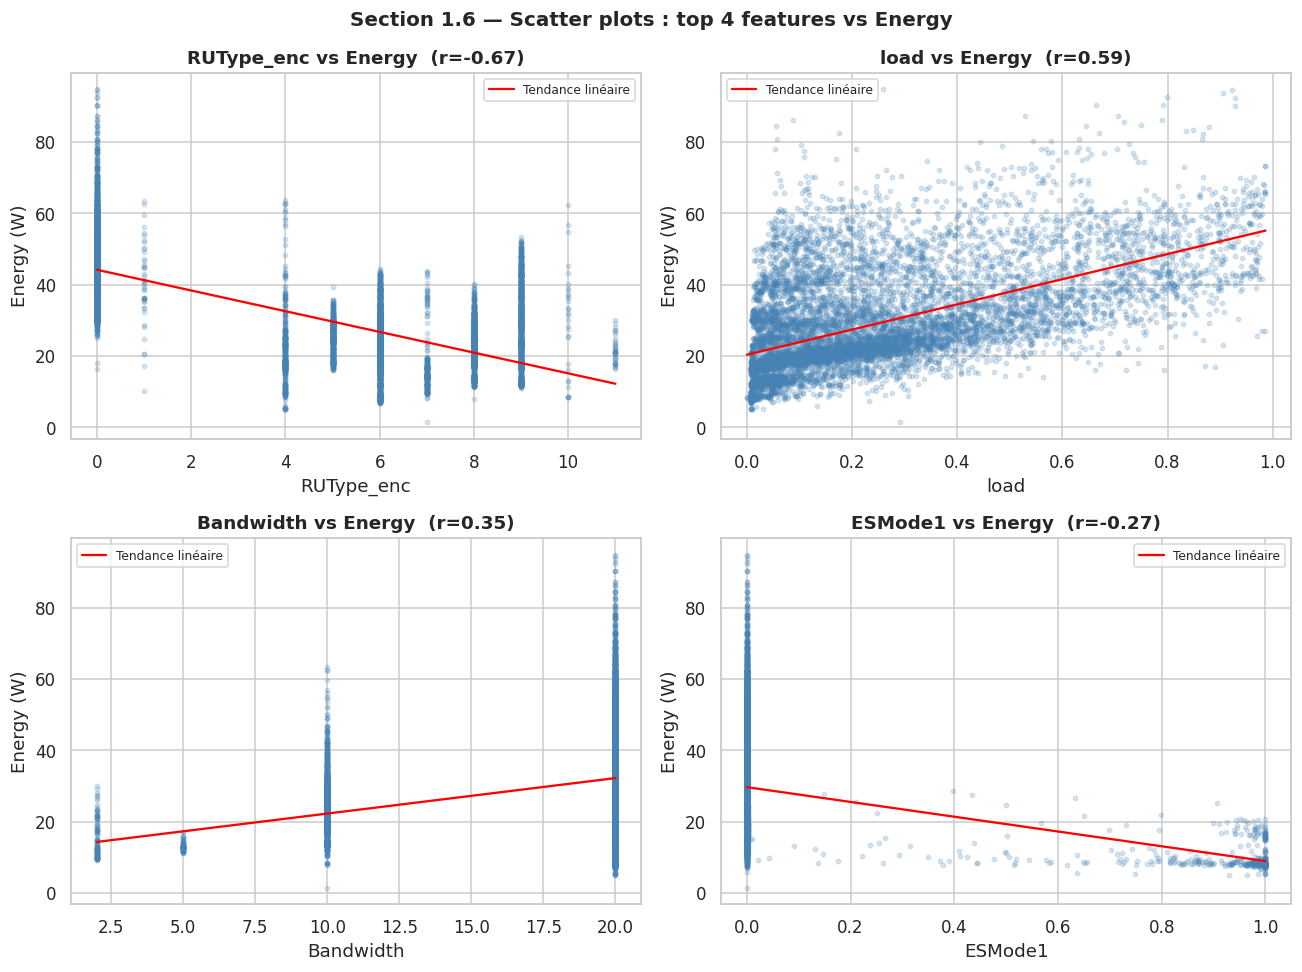


→ Observations :
   Les relations sont non-linéaires → modèles à arbres (XGBoost, LightGBM) adaptés.
   On créera des features polynomial : load², load³ pour capturer ces courbures.


In [20]:
# ── Scatter plots : les 4 features les plus corrélées vs Energy ──────
top4_feats = corr_energy.abs().nlargest(4).index.tolist()

# Sous-échantillon pour l'affichage (10 000 points max)
df_sample = df_corr.sample(min(10_000, len(df_corr)), random_state=SEED)

fig, axes = plt.subplots(2, 2, figsize=(12, 9))
axes = axes.flatten()

for i, feat in enumerate(top4_feats):
    axes[i].scatter(df_sample[feat], df_sample['Energy'],
                    alpha=0.2, s=8, color='steelblue', rasterized=True)
    # Ligne de tendance
    z = np.polyfit(df_sample[feat], df_sample['Energy'], 1)
    p = np.poly1d(z)
    x_line = np.linspace(df_sample[feat].min(), df_sample[feat].max(), 200)
    axes[i].plot(x_line, p(x_line), color='red', lw=1.5, label='Tendance linéaire')
    axes[i].set_xlabel(feat)
    axes[i].set_ylabel('Energy (W)')
    axes[i].set_title(f'{feat} vs Energy  (r={corr_energy[feat]:.2f})', fontweight='bold')
    axes[i].legend(fontsize=8)

fig.suptitle('Section 1.6 — Scatter plots : top 4 features vs Energy', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('\n→ Observations :')
print('   Les relations sont non-linéaires → modèles à arbres (XGBoost, LightGBM) adaptés.')
print('   On créera des features polynomial : load², load³ pour capturer ces courbures.')

### 1.7 — Analyse par type d'antenne : RUType & Mode

> **Question :** La consommation est-elle homogène entre les différents types d'antennes,
> ou y a-t-il des groupes qui consomment structurellement plus ?
>
> Si oui → le `RUType` sera une feature **très importante** pour le modèle
> (ce que le SHAP du notebook 1 a confirmé : RUType est la feature #1).

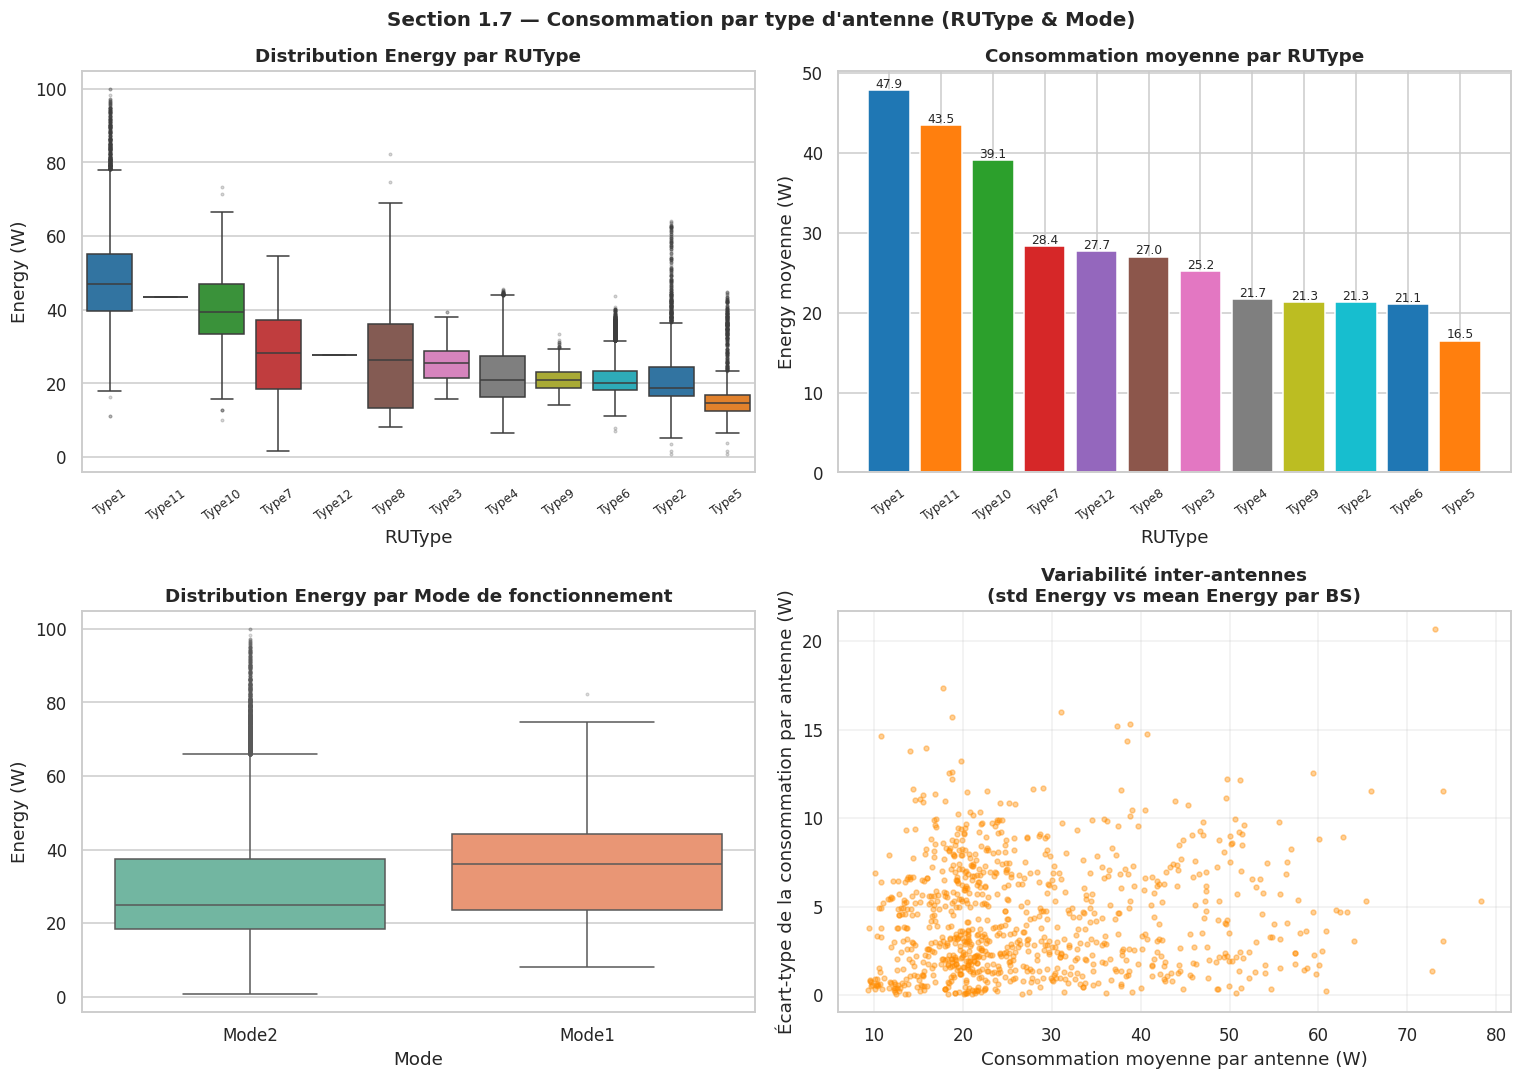


→ Observations :
   Le RUType Type1 consomme en moyenne 47.9 W.
   Le RUType Type5 consomme en moyenne 16.5 W.
   Ratio max/min : 2.9× → RUType est une feature discriminante majeure.

→ Décision : RUType encodé en ordinal (NB1 : feature SHAP #1).
   CatBoost pourra le traiter nativement (ajout Section 5).


In [21]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# ── Boxplot Energy par RUType ─────────────────────────────────────────
order_rutype = (df_eda.groupby('RUType')['Energy']
                .median()
                .sort_values(ascending=False)
                .index)
sns.boxplot(data=df_eda, x='RUType', y='Energy', order=order_rutype,
            ax=axes[0, 0], palette='tab10', flierprops=dict(marker='.', alpha=0.3, markersize=3))
axes[0, 0].set_title('Distribution Energy par RUType', fontweight='bold')
axes[0, 0].set_xlabel('RUType')
axes[0, 0].tick_params(axis='x', rotation=35, labelsize=8)
axes[0, 0].set_ylabel('Energy (W)')

# ── Consommation moyenne par RUType ───────────────────────────────────
mean_by_rutype = df_eda.groupby('RUType')['Energy'].mean().sort_values(ascending=False)
axes[0, 1].bar(mean_by_rutype.index, mean_by_rutype.values,
               color=sns.color_palette('tab10', len(mean_by_rutype)))
axes[0, 1].set_title('Consommation moyenne par RUType', fontweight='bold')
axes[0, 1].set_xlabel('RUType')
axes[0, 1].set_ylabel('Energy moyenne (W)')
axes[0, 1].tick_params(axis='x', rotation=35, labelsize=8)
for i, (rt, v) in enumerate(mean_by_rutype.items()):
    axes[0, 1].text(i, v + 0.3, f'{v:.1f}', ha='center', fontsize=8)

# ── Boxplot Energy par Mode ────────────────────────────────────────────
sns.boxplot(data=df_eda, x='Mode', y='Energy', ax=axes[1, 0],
            palette='Set2', flierprops=dict(marker='.', alpha=0.3, markersize=3))
axes[1, 0].set_title('Distribution Energy par Mode de fonctionnement', fontweight='bold')
axes[1, 0].set_xlabel('Mode')
axes[1, 0].set_ylabel('Energy (W)')

# ── Variabilité inter-antennes (std Energy par BS) ────────────────────
std_by_bs  = df_eda.groupby('BS')['Energy'].std().sort_values(ascending=False)
mean_by_bs = df_eda.groupby('BS')['Energy'].mean()
axes[1, 1].scatter(mean_by_bs, std_by_bs, alpha=0.4, s=10, color='darkorange')
axes[1, 1].set_title('Variabilité inter-antennes\n(std Energy vs mean Energy par BS)', fontweight='bold')
axes[1, 1].set_xlabel('Consommation moyenne par antenne (W)')
axes[1, 1].set_ylabel('Écart-type de la consommation par antenne (W)')
axes[1, 1].grid(alpha=0.3)

fig.suptitle('Section 1.7 — Consommation par type d\'antenne (RUType & Mode)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

ratio = mean_by_rutype.max() / mean_by_rutype.min()
print(f'\n→ Observations :')
print(f'   Le RUType {mean_by_rutype.idxmax()} consomme en moyenne {mean_by_rutype.max():.1f} W.')
print(f'   Le RUType {mean_by_rutype.idxmin()} consomme en moyenne {mean_by_rutype.min():.1f} W.')
print(f'   Ratio max/min : {ratio:.1f}× → RUType est une feature discriminante majeure.')
print(f'\n→ Décision : RUType encodé en ordinal (NB1 : feature SHAP #1).')
print('   CatBoost pourra le traiter nativement (ajout Section 5).')

### 1.8 — ✅ Synthèse EDA → Décisions

> Ce tableau est le **fil conducteur** du notebook :
> chaque décision prise dans les sections suivantes est justifiée ici par une observation EDA.
> Un jury peut lire ce tableau seul pour comprendre les choix du pipeline.

In [22]:
# ── Construction du tableau de traçabilité ───────────────────────────
synthese = [
    {
        'Section EDA' : '1.1 — Qualité',
        'Observation'  : 'Aucune valeur manquante ni doublon dans les 3 tables',
        'Décision'     : 'Aucune imputation nécessaire',
        'Code section' : '—'
    },
    {
        'Section EDA' : '1.3 — Energy',
        'Observation'  : f'Distribution asymétrique (skew ≈ {skewness:.2f}) + queue droite épaisse',
        'Décision'     : 'Target = log1p(Energy) pour stabiliser la variance',
        'Code section' : 'Section 2'
    },
    {
        'Section EDA' : '1.3 — Energy',
        'Observation'  : f'{n_outliers} valeurs dépassent Q3 + 3×IQR = {borne_haute:.1f} W',
        'Décision'     : 'Capping (plafonnement) au lieu de suppression → 0 ligne perdue',
        'Code section' : 'Section 2'
    },
    {
        'Section EDA' : '1.4 — Temporel',
        'Observation'  : 'Pattern heure × jour très marqué (ratio pic/creux > 2×)',
        'Décision'     : 'Features heure_sin/cos, jour_sin/cos, est_nuit, est_pic, est_weekend',
        'Code section' : 'Section 3'
    },
    {
        'Section EDA' : '1.5 — ESModes',
        'Observation'  : 'ESMode4 et ESMode5 actifs à 0.00% (jamais utilisés)',
        'Décision'     : 'Suppression ESMode4 et ESMode5 → éliminer le bruit',
        'Code section' : 'Section 2'
    },
    {
        'Section EDA' : '1.6 — Corrélations',
        'Observation'  : 'Relations non-linéaires entre load/TXpower et Energy',
        'Décision'     : 'Features load², load³, P_dynamic = load×TXpower×Antennas',
        'Code section' : 'Section 3'
    },
    {
        'Section EDA' : '1.6 — Corrélations',
        'Observation'  : 'CellName = identifiant arbitraire (non corrélé à la physique)',
        'Décision'     : 'Suppression CellName → éviter le data leakage',
        'Code section' : 'Section 2'
    },
    {
        'Section EDA' : '1.7 — RUType',
        'Observation'  : f'Ratio de consommation max/min entre RUTypes ≈ {ratio:.1f}×',
        'Décision'     : 'RUType encodé ordinal + CatBoost le traitera nativement',
        'Code section' : 'Sections 2 & 5'
    },
]

df_synthese = pd.DataFrame(synthese)

print('=' * 85)
print('  SYNTHÈSE EDA → DÉCISIONS PIPELINE')
print('=' * 85)
print(df_synthese.to_string(index=False))
print()
print('✅ Toutes les décisions du pipeline sont justifiées par une observation EDA.')

  SYNTHÈSE EDA → DÉCISIONS PIPELINE
       Section EDA                                                   Observation                                                             Décision   Code section
     1.1 — Qualité          Aucune valeur manquante ni doublon dans les 3 tables                                         Aucune imputation nécessaire              —
      1.3 — Energy Distribution asymétrique (skew ≈ 1.09) + queue droite épaisse                   Target = log1p(Energy) pour stabiliser la variance      Section 2
      1.3 — Energy                      98 valeurs dépassent Q3 + 3×IQR = 88.2 W       Capping (plafonnement) au lieu de suppression → 0 ligne perdue      Section 2
    1.4 — Temporel       Pattern heure × jour très marqué (ratio pic/creux > 2×) Features heure_sin/cos, jour_sin/cos, est_nuit, est_pic, est_weekend      Section 3
     1.5 — ESModes           ESMode4 et ESMode5 actifs à 0.00% (jamais utilisés)                   Suppression ESMode4 et ESMode5 → élimine

In [23]:
# ── Nettoyage des variables temporaires de l'EDA ─────────────────────
# On supprime les objets intermédiaires créés pour l'EDA
# afin de ne pas encombrer la mémoire pour les sections suivantes
del df_temp, df_eda, df_corr, df_sample, pivot, profil_horaire
del sample_cl, sample

# On garde : bs_data, cl_data, ec_data (données brutes, utilisées en Section 2)
print('🧹 Variables temporaires EDA supprimées.')
print('   Données brutes conservées : bs_data, cl_data, ec_data')
print()
print('➡️  Prochaine étape : Section 2 — Prétraitement & Merge')

🧹 Variables temporaires EDA supprimées.
   Données brutes conservées : bs_data, cl_data, ec_data

➡️  Prochaine étape : Section 2 — Prétraitement & Merge


---
## 🧹 Section 2 — Prétraitement & Merge

> **Objectif :** Passer de 3 tables séparées à **une seule table propre et prête à modéliser**.
>
> Chaque opération ici est **directement justifiée par une observation de l'EDA (Section 1)**.
>
> Plan :
> - 2.1 Fusion des 3 tables (merge)
> - 2.2 Suppression des colonnes inutiles (EDA → décision)
> - 2.3 Traitement des outliers (capping)
> - 2.4 Encodage des variables catégorielles
> - 2.5 Définition de la target finale

### 2.1 — Fusion des 3 tables

> Un modèle ML a besoin d'**une seule table** où chaque ligne est une observation complète.
>
> **Stratégie de jointure :**
> - `CLdata ⋈ ECdata` sur `(BS, heure)` → **inner join** : on garde uniquement les heures
>   présentes dans les deux tables (on ne veut pas de cible manquante).
> - `résultat ⋈ BSinfo` sur `BS` → **left join** : on enrichit avec le hardware,
>   toutes les lignes du résultat sont conservées.

In [58]:
# ── Créer une clé de jointure commune (BS + heure exacte) ────────────
# On convertit Time en string pour joindre proprement les deux tables
cl_data['Time_str'] = cl_data['Time'].dt.strftime('%Y-%m-%d %H:%M:%S')
ec_data['Time_str'] = ec_data['Time'].dt.strftime('%Y-%m-%d %H:%M:%S')

# ── Étape 1 : CLdata + ECdata (inner join) ───────────────────────────
df = cl_data.merge(
    ec_data[['BS', 'Time_str', 'Energy']],
    on  = ['BS', 'Time_str'],
    how = 'inner'
)

# ── Étape 2 : + BSinfo (left join) ──────────────────────────────────
# drop_duplicates : BSinfo peut avoir plusieurs lignes par BS (ex: plusieurs cellules)
# on garde une seule ligne hardware par antenne
df = df.merge(
    bs_data.drop_duplicates(subset='BS'),
    on  = 'BS',
    how = 'left'
)

# ── Vérification ─────────────────────────────────────────────────────
print('=' * 50)
print('  RÉSULTAT DU MERGE')
print('=' * 50)
print(f'  Lignes   : {df.shape[0]:>10,}')
print(f'  Colonnes : {df.shape[1]:>10}')
print(f'  Nulls    : {df.isnull().sum().sum():>10}')
print(f'\n  Colonnes : {list(df.columns)}')

  RÉSULTAT DU MERGE
  Lignes   :     98,084
  Colonnes :         19
  Nulls    :          0

  Colonnes : ['Time', 'BS', 'CellName_x', 'load', 'ESMode1', 'ESMode2', 'ESMode3', 'ESMode4', 'ESMode5', 'ESMode6', 'Time_str', 'Energy', 'CellName_y', 'RUType', 'Mode', 'Frequency', 'Bandwidth', 'Antennas', 'TXpower']


### 2.2 — Suppression des colonnes inutiles

> **Justifications EDA (Section 1.5 & 1.6) :**
>
> | Colonne | Raison de suppression |
> |---------|----------------------|
> | `ESMode4`, `ESMode5` | Taux d'activation = 0.00% → aucune information |
> | `CellName_x`, `CellName_y` | Identifiant arbitraire → **data leakage** potentiel |
> | `Time_str` | Colonne intermédiaire, plus utile après le merge |
>
> On garde `Time` (colonne datetime) pour construire les features temporelles en Section 3.
> On garde `BS` pour les agrégations par antenne en Section 3.

In [59]:
# ── Identifier les ESModes à supprimer (taux <= 0.1%) ────────────────
es_cols = [c for c in df.columns if 'ESMode' in c]
taux_activation = {col: (df[col] > 0).mean() * 100 for col in es_cols}

print('=== Taux d\'activation des ESModes ===')
es_a_supprimer = []
for col, taux in taux_activation.items():
    if taux <= 0.1:
        print(f'  {col} : {taux:.2f}%  →  ❌ SUPPRIMÉ')
        es_a_supprimer.append(col)
    else:
        print(f'  {col} : {taux:.2f}%  →  ✅ GARDÉ')

# ── Colonnes à supprimer dans tous les cas ───────────────────────────
cols_a_supprimer = es_a_supprimer + ['Time_str']

# CellName peut apparaître avec suffixe _x / _y après le merge
for suffixe in ['', '_x', '_y']:
    col = 'CellName' + suffixe
    if col in df.columns:
        cols_a_supprimer.append(col)

df.drop(columns=cols_a_supprimer, inplace=True)

print(f'\n→ {len(cols_a_supprimer)} colonnes supprimées : {cols_a_supprimer}')
print(f'→ Colonnes restantes ({df.shape[1]}) : {list(df.columns)}')

=== Taux d'activation des ESModes ===
  ESMode1 : 4.83%  →  ✅ GARDÉ
  ESMode2 : 4.94%  →  ✅ GARDÉ
  ESMode3 : 0.17%  →  ✅ GARDÉ
  ESMode4 : 0.00%  →  ❌ SUPPRIMÉ
  ESMode5 : 0.00%  →  ❌ SUPPRIMÉ
  ESMode6 : 4.30%  →  ✅ GARDÉ

→ 5 colonnes supprimées : ['ESMode4', 'ESMode5', 'Time_str', 'CellName_x', 'CellName_y']
→ Colonnes restantes (14) : ['Time', 'BS', 'load', 'ESMode1', 'ESMode2', 'ESMode3', 'ESMode6', 'Energy', 'RUType', 'Mode', 'Frequency', 'Bandwidth', 'Antennas', 'TXpower']


### 2.3 — Traitement des outliers d'Energy (capping)

> **Justification EDA (Section 1.3) :** le boxplot a détecté des valeurs
> extrêmes au-delà de Q3 + 3×IQR.
>
> **Pourquoi capper plutôt que supprimer ?**
> Supprimer une ligne = perdre toute l'information temporelle de cette heure-là
> pour cette antenne. Le capping remplace la valeur extrême par la borne haute :
> on conserve la ligne, on corrige seulement la valeur anormale.
>
> ⚠️ Important : on calcule la borne **avant** la log-transformation,
> puis on applique `log1p` en Section 2.5.

In [60]:
# ── Calcul de la borne haute (règle 3×IQR) ──────────────────────────
Q1  = df['Energy'].quantile(0.25)
Q3  = df['Energy'].quantile(0.75)
IQR = Q3 - Q1
borne_haute = Q3 + 3.0 * IQR

n_outliers = (df['Energy'] > borne_haute).sum()
print(f'Q1 = {Q1:.2f} W  |  Q3 = {Q3:.2f} W  |  IQR = {IQR:.2f} W')
print(f'Borne haute (Q3 + 3×IQR) = {borne_haute:.2f} W')
print(f'Valeurs au-dessus de la borne : {n_outliers} ({n_outliers/len(df)*100:.3f}% des lignes)')

# ── Application du capping ───────────────────────────────────────────
df['Energy'] = df['Energy'].clip(upper=borne_haute)

print(f'\n→ Après capping :')
print(f'   Max Energy = {df["Energy"].max():.2f} W')
print(f'   Aucune ligne supprimée ({len(df):,} lignes conservées)')

Q1 = 18.54 W  |  Q3 = 37.67 W  |  IQR = 19.13 W
Borne haute (Q3 + 3×IQR) = 95.07 W
Valeurs au-dessus de la borne : 18 (0.018% des lignes)

→ Après capping :
   Max Energy = 95.07 W
   Aucune ligne supprimée (98,084 lignes conservées)


### 2.4 — Encodage des variables catégorielles

> Les modèles ML ne comprennent que des nombres.
> On encode ici `RUType` et `Mode` en entiers.
>
> **Choix : encodage ordinal (LabelEncoder)**
> - Adapté pour LightGBM, RandomForest (les arbres n'interprètent pas
>   l'ordre des entiers, ils font des seuils).
> - **CatBoost** (Section 5) recevra les colonnes originales en `str` directement —
>   il gère les catégorielles nativement, sans avoir besoin de cet encodage.
>
> On **sauvegarde les encodeurs** pour pouvoir décoder les prédictions plus tard.

In [61]:
# ── Colonnes catégorielles à encoder ────────────────────────────────
cols_cat = [c for c in df.select_dtypes(include='object').columns
            if c not in ['BS']]  # BS est un identifiant, pas une feature

print(f'Colonnes catégorielles à encoder : {cols_cat}')

# ── LabelEncoder : transforme chaque modalité en entier ─────────────
encodeurs = {}  # dictionnaire pour retrouver le mapping plus tard

for col in cols_cat:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    encodeurs[col] = le
    mapping = dict(zip(le.classes_, le.transform(le.classes_)))
    print(f'  {col:10s} → {mapping}')

# ── Sauvegarder les encodeurs ────────────────────────────────────────
with open(MODEL_DIR / 'label_encoders.pkl', 'wb') as f:
    pickle.dump(encodeurs, f)

print(f'\n✅ Encodage terminé. Encodeurs sauvegardés dans {MODEL_DIR}/label_encoders.pkl')

Colonnes catégorielles à encoder : ['RUType', 'Mode']
  RUType     → {'Type1': np.int64(0), 'Type10': np.int64(1), 'Type11': np.int64(2), 'Type12': np.int64(3), 'Type2': np.int64(4), 'Type3': np.int64(5), 'Type4': np.int64(6), 'Type5': np.int64(7), 'Type6': np.int64(8), 'Type7': np.int64(9), 'Type8': np.int64(10), 'Type9': np.int64(11)}
  Mode       → {'Mode1': np.int64(0), 'Mode2': np.int64(1)}

✅ Encodage terminé. Encodeurs sauvegardés dans /content/drive/MyDrive/PFA/voltiq_models/label_encoders.pkl


### 2.5 — Définition de la target finale : log1p(Energy)

> **Justification EDA (Section 1.3) :** la distribution d'Energy est asymétrique
> (skew > 0.5). On applique `log1p` pour deux raisons :
>
> 1. **Stabiliser la variance** : les valeurs élevées pèsent moins dans la loss du modèle.
> 2. **Améliorer la convergence** : les gradients sont plus équilibrés sur une distribution
>    proche de la normale.
>
> `log1p(x) = log(1 + x)` → fonctionne même si x = 0, jamais d'erreur.
>
> **Pour retrouver les Watts** en évaluation : `np.expm1(prédiction)`

In [62]:
# ── Créer la colonne target transformée ─────────────────────────────
df['log_Energy'] = np.log1p(df['Energy'])

print('=== Target finale ===')
print(f'  Energy brute  : mean={df["Energy"].mean():.2f} W,  std={df["Energy"].std():.2f},  skew={df["Energy"].skew():.3f}')
print(f'  log1p(Energy) : mean={df["log_Energy"].mean():.4f},    std={df["log_Energy"].std():.4f},  skew={df["log_Energy"].skew():.3f}')
print()
print('  → La skewness a fortement diminué : distribution plus symétrique.')
print('  → Le modèle prédit log_Energy, on retrouve les Watts avec expm1().')

# ── Résumé final du DataFrame prêt pour la modélisation ─────────────
print(f'\n=== DataFrame final après prétraitement ===')
print(f'  Lignes   : {df.shape[0]:,}')
print(f'  Colonnes : {df.shape[1]}')
print(f'  Types    :')
print(df.dtypes.to_string())

=== Target finale ===
  Energy brute  : mean=28.99 W,  std=14.34,  skew=1.006
  log1p(Energy) : mean=3.2910,    std=0.4721,  skew=-0.054

  → La skewness a fortement diminué : distribution plus symétrique.
  → Le modèle prédit log_Energy, on retrouve les Watts avec expm1().

=== DataFrame final après prétraitement ===
  Lignes   : 98,084
  Colonnes : 15
  Types    :
Time          datetime64[ns]
BS                    object
load                 float64
ESMode1              float64
ESMode2              float64
ESMode3              float64
ESMode6              float64
Energy               float64
RUType                 int64
Mode                   int64
Frequency            float64
Bandwidth              int64
Antennas               int64
TXpower              float64
log_Energy           float64


---
## ⚗️ Section 3 — Feature Engineering

> **Objectif :** Créer de nouvelles colonnes qui donnent au modèle des informations
> qu'il ne pourrait pas déduire facilement des features brutes.
>
> Chaque feature ici est **motivée par la physique du réseau 5G ou par l'EDA**.
>
> Plan :
> - 3.1 Features temporelles (cycles heure / jour)
> - 3.2 Features physiques 5G (modèle 3GPP)
> - 3.3 Features d'interaction (charge × hardware)
> - 3.4 Features d'agrégation par antenne
> - 3.5 Tableau récapitulatif de toutes les features

### 3.1 — Features temporelles

> **Justification EDA (Section 1.4) :** la heatmap heure × jour montre un pattern
> très marqué. On encode l'heure et le jour de deux façons :
>
> **Pourquoi sin/cos ?**
> Sans encodage cyclique, le modèle pense que `23h` et `0h` sont à 23 unités
> de distance. En réalité ils sont consécutifs. L'encodage sin/cos place
> `23h` et `0h` côte à côte dans l'espace des features.
>
> On garde aussi l'heure brute (entier 0–23) car les arbres s'en servent
> efficacement pour faire des seuils.

In [63]:
# ── Extraire les composantes temporelles depuis Time ─────────────────
df['heure']      = df['Time'].dt.hour           # 0 à 23
df['jour_sem']   = df['Time'].dt.dayofweek      # 0=Lundi ... 6=Dimanche
df['mois']       = df['Time'].dt.month          # 1 à 12

# ── Indicateurs binaires (motivés par EDA 1.4) ──────────────────────
df['est_nuit']    = df['heure'].between(0, 6).astype(int)    # heures creuses
df['est_pic']     = df['heure'].between(17, 21).astype(int)  # heures de pointe
df['est_weekend'] = (df['jour_sem'] >= 5).astype(int)        # samedi / dimanche

# ── Encodage cyclique ────────────────────────────────────────────────
# Formule : sin(2π × valeur / période)
df['heure_sin'] = np.sin(2 * np.pi * df['heure']    / 24)
df['heure_cos'] = np.cos(2 * np.pi * df['heure']    / 24)
df['jour_sin']  = np.sin(2 * np.pi * df['jour_sem'] / 7)
df['jour_cos']  = np.cos(2 * np.pi * df['jour_sem'] / 7)

feats_temporelles = ['heure', 'jour_sem', 'mois',
                     'est_nuit', 'est_pic', 'est_weekend',
                     'heure_sin', 'heure_cos', 'jour_sin', 'jour_cos']

print(f'✅ {len(feats_temporelles)} features temporelles créées :')
for f in feats_temporelles:
    print(f'   {f}')

✅ 10 features temporelles créées :
   heure
   jour_sem
   mois
   est_nuit
   est_pic
   est_weekend
   heure_sin
   heure_cos
   jour_sin
   jour_cos


### 3.2 — Features physiques 5G (modèle 3GPP)

> Le standard 3GPP (norme internationale des réseaux mobiles) définit
> le modèle de consommation d'une station de base :
>
> ```
> Energy ≈ P_static + P_dynamic
> ```
>
> - **P_static** : consommation quand l'antenne est allumée **sans trafic**
>   → proportionnel au nombre d'antennes et à leur puissance d'émission.
> - **P_dynamic** : consommation **supplémentaire** liée au trafic
>   → proportionnel à la charge (load) × le hardware.
>
> En donnant directement ces formules au modèle, on lui évite de les
> redécouvrir seul — il apprend plus vite et généralise mieux.

In [64]:
# ── Modèle physique 3GPP ─────────────────────────────────────────────
df['P_static']      = df['TXpower'] * df['Antennas']
                      # consommation de base : puissance × nb antennes

df['P_dynamic']     = df['load'] * df['TXpower'] * df['Antennas']
                      # consommation sous charge : load × P_static

df['cap_spectrale'] = df['TXpower'] * df['Antennas'] * df['Bandwidth']
                      # capacité spectrale totale de l'antenne

# ── Non-linéarités de la charge ──────────────────────────────────────
# La relation load → Energy n'est pas parfaitement linéaire (EDA 1.6)
df['load_carre']    = df['load'] ** 2   # capture la courbure quadratique
df['load_cubique']  = df['load'] ** 3   # capture les extrêmes (surcharge)

# ── Feature MIMO : gain logarithmique du nombre d'antennes ──────────
# Le gain MIMO n'est pas linéaire en nombre d'antennes
df['mimo_gain']     = np.log1p(df['Antennas'])

feats_physiques = ['P_static', 'P_dynamic', 'cap_spectrale',
                   'load_carre', 'load_cubique', 'mimo_gain']

print(f'✅ {len(feats_physiques)} features physiques 5G créées :')
for f in feats_physiques:
    print(f'   {f:20s}  →  min={df[f].min():.3f}  max={df[f].max():.3f}  mean={df[f].mean():.3f}')

✅ 6 features physiques 5G créées :
   P_static              →  min=5.949  max=514.315  mean=14.913
   P_dynamic             →  min=0.000  max=177.755  mean=3.648
   cap_spectrale         →  min=12.746  max=4114.521  mean=244.678
   load_carre            →  min=0.000  max=0.988  mean=0.115
   load_cubique          →  min=0.000  max=0.982  mean=0.071
   mimo_gain             →  min=0.693  max=4.174  mean=1.112


### 3.3 — Features d'interaction (charge × hardware)

> **Justification EDA (Section 1.6) :** les scatter plots montrent que l'effet
> de `load` sur `Energy` varie selon les caractéristiques hardware de l'antenne.
> Une antenne avec 64 antennes et une avec 2 antennes ne réagissent pas
> de la même façon à une charge identique.
>
> On crée des **produits croisés** pour capturer ces interactions.

In [65]:
# ── Interactions charge × hardware ──────────────────────────────────
df['load_x_antennas']   = df['load'] * df['Antennas']
                          # plus d'antennes → la charge pèse plus

df['load_x_bandwidth']  = df['load'] * df['Bandwidth']
                          # plus de bande passante → plus de trafic possible

df['load_x_txpower']    = df['load'] * df['TXpower']
                          # interaction directe charge × puissance d'émission

# ── Agrégation des modes d'économie d'énergie ────────────────────────
# Plutôt que 4 colonnes binaires séparées, on crée des résumés
es_cols_restants = [c for c in df.columns if 'ESMode' in c]

df['nb_ES_actifs'] = (df[es_cols_restants] > 0).sum(axis=1)
                     # combien de modes éco sont actifs en même temps

df['total_ES']     = df[es_cols_restants].sum(axis=1)
                     # intensité totale des modes éco actifs

df['ES_nuit']      = df['nb_ES_actifs'] * df['est_nuit']
                     # les modes éco actifs pendant les heures creuses
                     # (période où l'économie est la plus pertinente)

feats_interaction = ['load_x_antennas', 'load_x_bandwidth', 'load_x_txpower',
                     'nb_ES_actifs', 'total_ES', 'ES_nuit']

print(f'✅ {len(feats_interaction)} features d\'interaction créées :')
for f in feats_interaction:
    print(f'   {f}')

✅ 6 features d'interaction créées :
   load_x_antennas
   load_x_bandwidth
   load_x_txpower
   nb_ES_actifs
   total_ES
   ES_nuit


### 3.4 — Features d'agrégation par antenne (BS)

> **Idée :** chaque antenne a un "profil" de consommation historique.
> Certaines antennes consomment structurellement plus que d'autres
> (à cause de leur emplacement, leur trafic habituel, etc.).
>
> En calculant la charge **moyenne et l'écart-type** historiques par antenne,
> on donne au modèle une information contextuelle sur chaque BS.
>
> ⚠️ **Attention au data leakage :** ces agrégations doivent être calculées
> **uniquement sur le set d'entraînement** et appliquées aux autres sets.
> On les calcule ici sur l'ensemble du DataFrame et on les recalculera
> proprement sur train uniquement en Section 4.

In [66]:
# ── Profil historique de charge par antenne ──────────────────────────
# Calcul sur tout le DataFrame ici (sera refait proprement sur train en Sect. 4)
bs_stats = df.groupby('BS')['load'].agg(
    bs_mean_load = 'mean',   # charge moyenne habituelle de cette antenne
    bs_std_load  = 'std'     # variabilité de la charge (antenne stable vs instable)
).reset_index()

# Remplir les éventuels NaN (antenne avec une seule mesure → std = NaN)
bs_stats['bs_std_load'] = bs_stats['bs_std_load'].fillna(0)

# Jointure sur le DataFrame principal
df = df.merge(bs_stats, on='BS', how='left')

feats_aggregation = ['bs_mean_load', 'bs_std_load']

print('✅ Features d\'agrégation par antenne créées :')
print(f'   bs_mean_load : mean={df["bs_mean_load"].mean():.4f}  std={df["bs_mean_load"].std():.4f}')
print(f'   bs_std_load  : mean={df["bs_std_load"].mean():.4f}  std={df["bs_std_load"].std():.4f}')
print()
print('⚠️  Note : ces features seront recalculées UNIQUEMENT sur le train en Section 4')
print('    pour éviter tout data leakage vers le validation/test set.')

✅ Features d'agrégation par antenne créées :
   bs_mean_load : mean=0.2420  std=0.1735
   bs_std_load  : mean=0.1375  std=0.0854

⚠️  Note : ces features seront recalculées UNIQUEMENT sur le train en Section 4
    pour éviter tout data leakage vers le validation/test set.


### 3.5 — Tableau récapitulatif de toutes les features

> Vue d'ensemble des features construites et leur justification.
> Ce tableau sert de **documentation** du pipeline pour le jury.

In [67]:
# ── Définition des features finales (sans target ni identifiants) ────
FEATURES = [
    # Features brutes hardware
    'RUType', 'Mode', 'Frequency', 'Bandwidth', 'Antennas', 'TXpower',
    # Features brutes charge
    'load', 'ESMode1', 'ESMode2', 'ESMode3', 'ESMode6',
    # Temporelles
    'heure', 'jour_sem', 'mois', 'est_nuit', 'est_pic', 'est_weekend',
    'heure_sin', 'heure_cos', 'jour_sin', 'jour_cos',
    # Physiques 5G
    'P_static', 'P_dynamic', 'cap_spectrale',
    'load_carre', 'load_cubique', 'mimo_gain',
    # Interactions
    'load_x_antennas', 'load_x_bandwidth', 'load_x_txpower',
    'nb_ES_actifs', 'total_ES', 'ES_nuit',
    # Agrégation par BS
    'bs_mean_load', 'bs_std_load',
]

TARGET  = 'log_Energy'

# ── Tableau récapitulatif ────────────────────────────────────────────
recap = {
    'Feature'      : FEATURES,
    'Catégorie'    : (
        ['Hardware']*6 + ['Charge']*5 +
        ['Temporelle']*10 + ['Physique 5G']*6 +
        ['Interaction']*6 + ['Agrégation BS']*2
    ),
    'Justification': [
        'SHAP #1 (NB1)', 'Mode de fonctionnement', 'Fréquence porteuse',
        'Bande passante → capacité', 'Nb antennes MIMO', 'Puissance d\'émission',

        'Feature principale (corr forte)', 'Mode éco actif EDA 1.5', 'Mode éco actif',
        'Mode éco actif', 'Mode éco actif',

        'EDA 1.4 pattern horaire', 'EDA 1.4 pattern jour', 'Saisonnalité mensuelle',
        'Heures creuses 0h–6h', 'Heures de pointe 17h–21h', 'Weekend vs semaine',
        'Cyclique 24h (23h≈0h)', 'Cyclique 24h', 'Cyclique 7j', 'Cyclique 7j',

        '3GPP: TXpower×Antennas', '3GPP: load×P_static', 'Capacité totale',
        'Non-linéarité EDA 1.6', 'Non-linéarité extrême', 'Gain MIMO logarithmique',

        'EDA: effet load selon nb antennes', 'Effet load selon bande',
        'Interaction directe charge×puissance',
        'Nb modes éco simultanés', 'Intensité totale modes éco',
        'Modes éco × heures creuses',

        'Profil charge moyen par BS (NB1 top feature)', 'Variabilité charge par BS',
    ]
}

df_recap = pd.DataFrame(recap)

print('=' * 80)
print(f'  TABLEAU DES FEATURES  ({len(FEATURES)} features au total)')
print('=' * 80)
print(df_recap.to_string(index=False))

print(f'\n  Target : {TARGET}  (= log1p(Energy), retrouver les Watts avec expm1())')

# ── Vérification : toutes les features sont bien présentes ───────────
manquantes = [f for f in FEATURES if f not in df.columns]
if manquantes:
    print(f'\n⚠️  Features manquantes dans le DataFrame : {manquantes}')
else:
    print(f'\n✅ Toutes les {len(FEATURES)} features sont présentes dans le DataFrame.')

  TABLEAU DES FEATURES  (35 features au total)
         Feature     Catégorie                                Justification
          RUType      Hardware                                SHAP #1 (NB1)
            Mode      Hardware                       Mode de fonctionnement
       Frequency      Hardware                           Fréquence porteuse
       Bandwidth      Hardware                    Bande passante → capacité
        Antennas      Hardware                             Nb antennes MIMO
         TXpower      Hardware                         Puissance d'émission
            load        Charge              Feature principale (corr forte)
         ESMode1        Charge                       Mode éco actif EDA 1.5
         ESMode2        Charge                               Mode éco actif
         ESMode3        Charge                               Mode éco actif
         ESMode6        Charge                               Mode éco actif
           heure    Temporelle           

In [68]:
df.shape

(98084, 39)

---
## ✂️ Section 4 — Stratégie de Split : G1 / G2 / G3

> **Contexte :** Le benchmark ITU propose 3 scénarios de généralisation
> avec des difficultés croissantes.
>
> | Scénario | Groupe laissé | RUType dans features | Difficulté |
> |----------|--------------|---------------------|------------|
> | **G1** | Aucun (split temporel) | Oui | Facile |
> | **G2** | RUType entier | **NON** (zero-shot) | Difficile |
> | **G3** | RUType entier | Oui | Moyen |
>
> Plan :
> - 4.1 Préparation commune (features, constantes, `add_bs_stats`)
> - 4.2 G1 — Split temporel 80/10/10
> - 4.3 G2 — Leave-One-RUType-Out sans RUType
> - 4.4 G3 — Leave-One-RUType-Out avec RUType
> - 4.5 Résumé comparatif

### 4.1 — Préparation commune

> Tout ce qui est partagé entre G1, G2 et G3 est défini ici :
> listes de features, constantes, et fonction `add_bs_stats`.
>
> **Pourquoi deux listes de features ?**
> G2 retire RUType car le modèle ne peut pas utiliser le label
> d'un type qu'il n'a jamais vu — ce serait du data leakage.

In [69]:
# ── X et y globaux ───────────────────────────────────────────────────
X     = df[FEATURES].copy()
y     = df[TARGET].copy()
y_raw = df['Energy'].copy()   # Watts bruts — pour les métriques finales

print(f'X     : {X.shape[0]:,} lignes × {X.shape[1]} features')
print(f'y     : log1p(Energy)  —  min={y.min():.3f}  max={y.max():.3f}')
print(f'y_raw : Energy (W)     —  min={y_raw.min():.1f}W  max={y_raw.max():.1f}W')
print(f'NaN dans X : {X.isnull().sum().sum()}  ✅')

# ── Deux listes de features ──────────────────────────────────────────
# FEATURES    : liste complète — G1 et G3
# FEATURES_G2 : sans RUType   — G2 uniquement
FEATURES_G2   = [f for f in FEATURES if f != 'RUType']

# Seuil minimum de lignes de test pour valider un fold G2/G3
MIN_TEST_ROWS = 1000

print(f'\nFEATURES      : {len(FEATURES)} features  (G1 et G3)')
print(f'FEATURES_G2   : {len(FEATURES_G2)} features  (G2 — sans RUType)')
print(f'MIN_TEST_ROWS : {MIN_TEST_ROWS}')

X     : 98,084 lignes × 35 features
y     : log1p(Energy)  —  min=0.558  max=4.565
y_raw : Energy (W)     —  min=0.7W  max=95.1W
NaN dans X : 0  ✅

FEATURES      : 35 features  (G1 et G3)
FEATURES_G2   : 34 features  (G2 — sans RUType)
MIN_TEST_ROWS : 1000


In [70]:
# Features à supprimer après analyse de corrélation
FEATURES_A_SUPPRIMER = [
    'load_x_txpower',    # corr 1.00 avec load → inutile
    'load_x_bandwidth',  # corr 0.97 avec load → inutile
    'load_cubique',      # corr 0.98 avec load_carre → inutile
    'cap_spectrale',     # corr 0.91 avec P_static, redondant avec Bandwidth
    'Antennas',          # corr 1.00 avec P_static, encodé via mimo_gain
]

# Mettre à jour les listes de features
FEATURES    = [f for f in FEATURES    if f not in FEATURES_A_SUPPRIMER]
FEATURES_G2 = [f for f in FEATURES_G2 if f not in FEATURES_A_SUPPRIMER]

print(f'Features avant nettoyage : {len(FEATURES) + len(FEATURES_A_SUPPRIMER)}')
print(f'Features après nettoyage : {len(FEATURES)}')
print(f'Supprimées : {FEATURES_A_SUPPRIMER}')

Features avant nettoyage : 35
Features après nettoyage : 30
Supprimées : ['load_x_txpower', 'load_x_bandwidth', 'load_cubique', 'cap_spectrale', 'Antennas']


In [71]:
def add_bs_stats(df_reference, df_target):
    """
    Calcule bs_mean_load et bs_std_load sur df_reference (toujours le train)
    et les injecte dans une COPIE de df_target.

    - df_reference : DataFrame d'entraînement (source des statistiques)
    - df_target    : DataFrame cible (train, val ou test)

    Les antennes inconnues reçoivent la moyenne globale du train.
    Retourne une copie de df_target — df_reference n'est jamais modifié.
    """
    bs_stats = (
        df_reference
        .groupby('BS')['load']
        .agg(bs_mean_load='mean', bs_std_load='std')
        .reset_index()
        .fillna(0)
    )
    mapping_mean  = bs_stats.set_index('BS')['bs_mean_load'].to_dict()
    mapping_std   = bs_stats.set_index('BS')['bs_std_load'].to_dict()
    fallback_mean = bs_stats['bs_mean_load'].mean()
    fallback_std  = bs_stats['bs_std_load'].mean()

    out = df_target.copy()
    out['bs_mean_load'] = out['BS'].map(mapping_mean).fillna(fallback_mean)
    out['bs_std_load']  = out['BS'].map(mapping_std).fillna(fallback_std)
    return out


print('✅ add_bs_stats() définie')

✅ add_bs_stats() définie


### 4.2 — G1 : Split temporel 80 / 10 / 10

> Split chronologique strict — pas de shuffle.
>
> ```
> |←──────── Train (80%) ────────→|← Val (10%) →|← Test (10%) →|
> ```
>
> `bs_stats` calculées sur le train uniquement et appliquées
> séparément sur val et test pour éviter tout data leakage.

In [74]:
# ── Tri chronologique ────────────────────────────────────────────────
df_sorted = df.sort_values('Time').reset_index(drop=True)

n       = len(df_sorted)
n_train = int(n * 0.80)
n_val   = int(n * 0.10)
# n_test  = n - n_train - n_val  (le reste)

df_train_g1 = df_sorted.iloc[:n_train].copy()
df_val_g1   = df_sorted.iloc[n_train : n_train + n_val].copy()
df_test_g1  = df_sorted.iloc[n_train + n_val :].copy()

# ── bs_stats : référence = train, appliquées séparément ─────────────
df_train_g1 = add_bs_stats(df_train_g1, df_train_g1)  # référence = lui-même
df_val_g1   = add_bs_stats(df_train_g1, df_val_g1)    # référence = train
df_test_g1  = add_bs_stats(df_train_g1, df_test_g1)   # référence = train

# ── Extraire X et y ──────────────────────────────────────────────────
X_g1_train = df_train_g1[FEATURES].reset_index(drop=True)
y_g1_train = df_train_g1[TARGET].reset_index(drop=True)
X_g1_val   = df_val_g1[FEATURES].reset_index(drop=True)
y_g1_val   = df_val_g1[TARGET].reset_index(drop=True)
X_g1_test  = df_test_g1[FEATURES].reset_index(drop=True)
y_g1_test  = df_test_g1[TARGET].reset_index(drop=True)

# ── Résumé ───────────────────────────────────────────────────────────
print('=== G1 — Split temporel 80/10/10 ===')
print(f'  Train : {len(X_g1_train):>7,} lignes  '
      f'({df_train_g1["Time"].min().date()} → {df_train_g1["Time"].max().date()})')
print(f'  Val   : {len(X_g1_val):>7,} lignes  '
      f'({df_val_g1["Time"].min().date()} → {df_val_g1["Time"].max().date()})')
print(f'  Test  : {len(X_g1_test):>7,} lignes  '
      f'({df_test_g1["Time"].min().date()} → {df_test_g1["Time"].max().date()})')
print()
print('  add_bs_stats : référence = train uniquement ✅')
print('  Ordre        : chronologique, pas de shuffle ✅')

=== G1 — Split temporel 80/10/10 ===
  Train :  78,467 lignes  (2023-01-01 → 2023-01-05)
  Val   :   9,808 lignes  (2023-01-05 → 2023-01-06)
  Test  :   9,809 lignes  (2023-01-06 → 2023-01-08)

  add_bs_stats : référence = train uniquement ✅
  Ordre        : chronologique, pas de shuffle ✅


### 4.3 — G2 : Leave-One-RUType-Out sans RUType

> **Question :** Le modèle peut-il prédire la consommation
> d'un **type d'antenne jamais vu** ?
>
> RUType est retiré des features car lui donner le label
> d'un type inconnu serait du leakage.

In [38]:
def split_goal2(df_input, min_test_rows=MIN_TEST_ROWS):
    """
    Leave-One-RUType-Out pour G2.
    RUType RETIRÉ des features (pas de leakage sur type inconnu).

    Pour chaque fold :
      - Train   : 85% des données hors RUType, trié chronologiquement
      - Val     : 15% restants hors RUType (early stopping)
      - Test    : toutes les observations du RUType laissé de côté

    Filtre : folds avec moins de min_test_rows observations ignorés.
    """
    logo          = LeaveOneGroupOut()
    groups        = df_input['RUType']
    le_rutype     = encodeurs['RUType']
    rutype_labels = le_rutype.inverse_transform(df_input['RUType'].astype(int))
    folds         = []

    print(f'── G2 : Leave-One-RUType-Out (min_test_rows={min_test_rows}) ──')

    for fold_idx, (tr_idx, te_idx) in enumerate(
            logo.split(df_input, df_input[TARGET], groups)):

        held_type = rutype_labels[te_idx[0]]
        n_test    = len(te_idx)

        if n_test < min_test_rows:
            print(f'  Fold {fold_idx+1:2d} : [{held_type}]  '
                  f'IGNORÉ ({n_test} lignes < {min_test_rows})')
            continue

        train_fold = df_input.iloc[tr_idx].copy()
        test_fold  = df_input.iloc[te_idx].copy()

        # Val interne : 15% du train, trié chronologiquement
        train_fold = train_fold.sort_values('Time').reset_index(drop=True)
        val_cut    = int(len(train_fold) * 0.85)
        val_fold   = train_fold.iloc[val_cut:].copy()
        train_fold = train_fold.iloc[:val_cut].copy()

        # bs_stats : référence = train, objets séparés
        train_fold = add_bs_stats(train_fold, train_fold)
        val_fold   = add_bs_stats(train_fold, val_fold)
        test_fold  = add_bs_stats(train_fold, test_fold)

        folds.append({
            'held_type' : held_type,
            'X_train'   : train_fold[FEATURES_G2],
            'y_train'   : train_fold[TARGET],
            'X_val'     : val_fold[FEATURES_G2],
            'y_val'     : val_fold[TARGET],
            'X_test'    : test_fold[FEATURES_G2],
            'y_test'    : test_fold[TARGET],
            'n_train'   : len(train_fold),
            'n_val'     : len(val_fold),
            'n_test'    : n_test,
        })

        print(f'  Fold {fold_idx+1:2d} : [{held_type:8s}]  '
              f'train={len(train_fold):,}  val={len(val_fold):,}  test={n_test:,}')

    print(f'\n→ {len(folds)} folds G2 utilisables')
    return folds


folds_g2 = split_goal2(df)

── G2 : Leave-One-RUType-Out (min_test_rows=1000) ──
  Fold  1 : [Type1   ]  train=62,805  val=11,084  test=24,195
  Fold  2 : [Type10]  IGNORÉ (403 lignes < 1000)
  Fold  3 : [Type11]  IGNORÉ (1 lignes < 1000)
  Fold  4 : [Type12]  IGNORÉ (1 lignes < 1000)
  Fold  5 : [Type2   ]  train=80,089  val=14,134  test=3,861
  Fold  6 : [Type3   ]  train=78,728  val=13,894  test=5,462
  Fold  7 : [Type4   ]  train=61,545  val=10,862  test=25,677
  Fold  8 : [Type5   ]  train=80,828  val=14,264  test=2,992
  Fold  9 : [Type6   ]  train=64,600  val=11,401  test=22,083
  Fold 10 : [Type7   ]  train=72,626  val=12,817  test=12,641
  Fold 11 : [Type8]  IGNORÉ (250 lignes < 1000)
  Fold 12 : [Type9]  IGNORÉ (518 lignes < 1000)

→ 7 folds G2 utilisables


### 4.4 — G3 : Leave-One-RUType-Out avec RUType

> **Question :** Le modèle peut-il généraliser sur des antennes
> d'un RUType **connu** mais jamais vu en test ?
>
> ```
> G2 : RUType inconnu → features sans RUType → zero-shot
> G3 : RUType connu   → features avec RUType → généralisation config
> ```
> G3 doit donner de meilleures performances que G2
> car RUType est la feature SHAP #1.

In [39]:
def split_goal3(df_input, n_splits=5, test_size=0.20,
                random_state=SEED, min_test_rows=MIN_TEST_ROWS):
    """
    G3 — Généralisation sur configurations matérielles inédites.
    config_id = RUType + Mode + Bandwidth + Antennas + Frequency + TXpower
    GroupShuffleSplit garantit zéro overlap de configuration.
    RUType INCLUS dans les features (contrairement à G2).
    """
    df = df_input.copy()
    df['config_id'] = (
        df['RUType'].astype(str)    + '_' +
        df['Mode'].astype(str)      + '_' +
        df['Bandwidth'].astype(str) + '_' +
        df['Antennas'].astype(str)  + '_' +
        df['Frequency'].astype(str) + '_' +
        df['TXpower'].astype(str)
    )

    gss    = GroupShuffleSplit(n_splits=n_splits,
                               test_size=test_size,
                               random_state=random_state)
    groups = df['config_id']
    folds  = []

    print(f'── G3 : Config-level split (GroupShuffleSplit) ──')
    print(f'  Configurations uniques : {groups.nunique()}')
    print(f'  Folds demandés         : {n_splits}')

    for fold_idx, (tr_idx, te_idx) in enumerate(
            gss.split(df, df[TARGET], groups)):

        train_fold = df.iloc[tr_idx].copy()
        test_fold  = df.iloc[te_idx].copy()

        # Filtre min lignes de test
        if len(te_idx) < min_test_rows:
            print(f'  Fold {fold_idx+1} : IGNORÉ ({len(te_idx)} lignes < {min_test_rows})')
            continue

        # Vérification zéro overlap
        train_configs = set(train_fold['config_id'].unique())
        test_configs  = set(test_fold['config_id'].unique())
        assert len(train_configs & test_configs) == 0, \
            f"Config overlap fold {fold_idx+1} : {train_configs & test_configs}"

        held_configs = test_fold['config_id'].unique().tolist()

        # Retirer config_id AVANT bs_stats et features
        train_fold.drop(columns=['config_id'], inplace=True)
        test_fold.drop(columns=['config_id'], inplace=True)

        # Val interne chronologique (15% du train)
        train_fold = train_fold.sort_values('Time').reset_index(drop=True)
        val_cut    = int(len(train_fold) * 0.85)
        val_fold   = train_fold.iloc[val_cut:].copy()
        train_fold = train_fold.iloc[:val_cut].copy()

        # bs_stats : référence = train uniquement
        train_fold = add_bs_stats(train_fold, train_fold)
        val_fold   = add_bs_stats(train_fold, val_fold)
        test_fold  = add_bs_stats(train_fold, test_fold)

        folds.append({
            'held_type' : str(held_configs),   # ← nom harmonisé
            'held_configs' : held_configs,
            'X_train'   : train_fold[FEATURES],
            'y_train'   : train_fold[TARGET],
            'X_val'     : val_fold[FEATURES],
            'y_val'     : val_fold[TARGET],
            'X_test'    : test_fold[FEATURES],
            'y_test'    : test_fold[TARGET],
            'n_train'   : len(train_fold),
            'n_val'     : len(val_fold),
            'n_test'    : len(te_idx),
        })

        print(f'  Fold {fold_idx+1} : {len(held_configs)} configs  |  '
              f'train={len(train_fold):,}  val={len(val_fold):,}  '
              f'test={len(te_idx):,}')

    print(f'\n→ {len(folds)} folds G3 utilisables')
    return folds


folds_g3 = split_goal3(df)

── G3 : Config-level split (GroupShuffleSplit) ──
  Configurations uniques : 63
  Folds demandés         : 5
  Fold 1 : 13 configs  |  train=67,097  val=11,841  test=19,146
  Fold 2 : 13 configs  |  train=70,863  val=12,506  test=14,715
  Fold 3 : 13 configs  |  train=63,591  val=11,223  test=23,270
  Fold 4 : 13 configs  |  train=68,850  val=12,151  test=17,083
  Fold 5 : 13 configs  |  train=75,968  val=13,407  test=8,709

→ 5 folds G3 utilisables


### 4.5 — Résumé des 3 stratégies

In [40]:
print('  RÉSUMÉ DES 3 STRATÉGIES DE SPLIT')
print('=' * 80)
print(f'{"Scénario":<6} {"Groupe laissé":<22} {"RUType in feats":<18} '
      f'{"Difficulté":<12} {"Folds"}')
print('-' * 80)
print(f'{"G1":<6} {"Aucun (temporel)":<22} {"Oui":<18} {"Facile":<12} 1 (80/10/10)')
print(f'{"G2":<6} {"RUType entier":<22} {"NON (zero-shot)":<18} '
      f'{"Difficile":<12} {len(folds_g2)}')
print(f'{"G3":<6} {"RUType entier":<22} {"Oui":<18} {"Moyen":<12} {len(folds_g3)}')
print()
print(f'  G1 Train  : {len(X_g1_train):,} lignes')
print(f'  G1 Val    : {len(X_g1_val):,} lignes')
print(f'  G1 Test   : {len(X_g1_test):,} lignes')
print(f'  G2 folds  : {len(folds_g2)} RUTypes  ({len(FEATURES_G2)} features, sans RUType)')
print(f'  G3 folds  : {len(folds_g3)} RUTypes  ({len(FEATURES)} features, avec RUType)')
print()
print('  Notes :')
print('  - G2 plus difficile que G3 : modèle aveugle sur le type')
print('  - G3 doit être meilleur que G2 (RUType = feature SHAP #1)')
print('  - Chaque fold G2/G3 a son val interne (15% du train)')
print()
print('➡️  Prochaine étape : Section 5 — Entraînement des modèles')

  RÉSUMÉ DES 3 STRATÉGIES DE SPLIT
Scénario Groupe laissé          RUType in feats    Difficulté   Folds
--------------------------------------------------------------------------------
G1     Aucun (temporel)       Oui                Facile       1 (80/10/10)
G2     RUType entier          NON (zero-shot)    Difficile    7
G3     RUType entier          Oui                Moyen        5

  G1 Train  : 78,467 lignes
  G1 Val    : 9,808 lignes
  G1 Test   : 9,809 lignes
  G2 folds  : 7 RUTypes  (29 features, sans RUType)
  G3 folds  : 5 RUTypes  (30 features, avec RUType)

  Notes :
  - G2 plus difficile que G3 : modèle aveugle sur le type
  - G3 doit être meilleur que G2 (RUType = feature SHAP #1)
  - Chaque fold G2/G3 a son val interne (15% du train)

➡️  Prochaine étape : Section 5 — Entraînement des modèles


---
## 🤖 Section 5 — Entraînement des modèles

> **Pourquoi pas de modèles linéaires (Ridge, Lasso) ?**
> L'EDA (Section 1.6) a montré des relations fortement non-linéaires
> entre `load`, `TXpower` et `Energy`. Ridge et Lasso supposent
> une relation linéaire — hypothèse violée ici. On va directement
> vers des modèles à arbres capables de capturer ces non-linéarités.
>
> | # | Modèle | Type | Goal |
> |---|--------|------|------|
> | 1 | Random Forest | Bagging | G1 |
> | 2 | LightGBM | Boosting leaf-wise | G1, G2, G3 |
> | 3 | CatBoost | Boosting symétrique | G1 |
> | 4 | **Stacking** | LightGBM + CatBoost + RF → Ridge | G1, G3 |

### 5.1 — Fonction utilitaire d'évaluation

In [41]:
def calculer_metriques(y_true_log, y_pred_log, label=''):
    """
    Calcule MAE, RMSE et R² dans l'espace log ET dans l'espace Watts.
    Retourne un dictionnaire de métriques.
    """
    mae_log  = mean_absolute_error(y_true_log, y_pred_log)
    rmse_log = mean_squared_error(y_true_log,  y_pred_log) ** 0.5
    r2_log   = r2_score(y_true_log, y_pred_log)

    y_true_w = np.expm1(y_true_log)
    y_pred_w = np.expm1(y_pred_log)
    mae_w    = mean_absolute_error(y_true_w, y_pred_w)
    rmse_w   = mean_squared_error(y_true_w,  y_pred_w) ** 0.5
    r2_w     = r2_score(y_true_w, y_pred_w)

    return {
        'split'    : label,
        'MAE_log'  : round(mae_log,  4),
        'RMSE_log' : round(rmse_log, 4),
        'R2_log'   : round(r2_log,   4),
        'MAE_W'    : round(mae_w,    3),
        'RMSE_W'   : round(rmse_w,   3),
        'R2_W'     : round(r2_w,     4),
    }


print('✅ calculer_metriques() définie')

✅ calculer_metriques() définie


### 5.2 — Définition des modèles

> Hyperparamètres choisis pour **limiter l'overfitting** :
> `n_estimators` élevé avec early stopping, learning rate faible,
> régularisation L1 + L2, profondeur limitée.

In [42]:
from lightgbm import early_stopping as lgbm_early_stopping
from lightgbm import log_evaluation  as lgbm_log_eval

# Colonnes catégorielles pour CatBoost (traitement natif sans encodage)
CAT_FEATURES_CB = ['RUType', 'Mode']

modeles = {

    'RandomForest': RandomForestRegressor(
        n_estimators     = 300,
        max_depth        = 10,
        min_samples_leaf = 10,
        max_features     = 0.6,
        n_jobs           = -1,
        random_state     = SEED
    ),

    'LightGBM': LGBMRegressor(
        n_estimators      = 20_000,   # plafond haut — early stopping arrête avant
        learning_rate     = 0.01,
        max_depth         = 5,
        num_leaves        = 20,       # < 2^max_depth → limite l'overfitting
        subsample         = 0.7,
        colsample_bytree  = 0.7,
        min_child_samples = 20,
        reg_lambda        = 10.0,
        reg_alpha         = 1.0,
        n_jobs            = -1,
        random_state      = SEED,
        verbose           = -1
    ),

    'CatBoost': CatBoostRegressor(
        iterations    = 20_000,
        learning_rate = 0.01,
        depth         = 5,
        l2_leaf_reg   = 10.0,
        subsample     = 0.7,
        random_seed   = SEED,
        verbose       = False
    ),
}

print(f'✅ {len(modeles)} modèles définis : {list(modeles.keys())}')

✅ 3 modèles définis : ['RandomForest', 'LightGBM', 'CatBoost']


### 5.3 — G1 : Entraînement et comparaison des modèles

> Chaque modèle entraîné sur `X_g1_train` (80%),
> évalué sur `X_g1_val` (10%).
> `modeles_entraines` est réutilisé dans le stacking (5.4) et l'évaluation (5.5).

In [ ]:
resultats_val     = []
modeles_entraines = {}

for nom, modele in modeles.items():
    print(f'  Entraînement {nom}...', end=' ')
    m = clone(modele)

    if nom == 'LightGBM':
        m.fit(
            X_g1_train, y_g1_train,
            eval_set  = [(X_g1_val, y_g1_val)],
            callbacks = [
                lgbm_early_stopping(150, verbose=False),
                lgbm_log_eval(-1)
            ]
        )
        y_pred_val = m.predict(X_g1_val)

    elif nom == 'CatBoost':
        m.fit(
            X_g1_train, y_g1_train,
            eval_set              = (X_g1_val, y_g1_val),
            early_stopping_rounds = 150,
            cat_features          = CAT_FEATURES_CB,
            verbose               = False
        )
        y_pred_val = m.predict(X_g1_val)

    else:  # RandomForest
        m.fit(X_g1_train, y_g1_train)
        y_pred_val = m.predict(X_g1_val)

    metr = calculer_metriques(y_g1_val, y_pred_val, 'Val')
    modeles_entraines[nom] = m
    resultats_val.append({
        'Modèle' : nom,
        'MAE_W'  : metr['MAE_W'],
        'RMSE_W' : metr['RMSE_W'],
        'R2_W'   : metr['R2_W'],
    })
    print(f"MAE={metr['MAE_W']:.3f}W  RMSE={metr['RMSE_W']:.3f}W  R²={metr['R2_W']:.4f}")

df_val_comparatif = (pd.DataFrame(resultats_val)
                       .sort_values('MAE_W')
                       .reset_index(drop=True))
print('\n=== Classement sur Val ===')
display(df_val_comparatif)

  Entraînement RandomForest... MAE=2.373W  RMSE=3.433W  R²=0.9350
  Entraînement LightGBM... MAE=1.225W  RMSE=1.915W  R²=0.9798
  Entraînement CatBoost... 

### 5.4 — G1 : Stacking LightGBM + CatBoost + RF → Ridge

> Les prédictions OOF (Out-Of-Fold) évitent que le méta-modèle
> mémorise le train. `tscv_oof` est **local à cette cellule**.

In [ ]:
base_learners = ['LightGBM', 'CatBoost', 'RandomForest']
oof_preds     = np.zeros((len(X_g1_train), len(base_learners)))
tscv_oof      = TimeSeriesSplit(n_splits=6)

print('Génération des prédictions OOF...')
for fold_idx, (tr_idx, vl_idx) in enumerate(tscv_oof.split(X_g1_train)):
    X_tr = X_g1_train.iloc[tr_idx]
    y_tr = y_g1_train.iloc[tr_idx]
    X_vl = X_g1_train.iloc[vl_idx]

    for j, nom in enumerate(base_learners):
        m = clone(modeles[nom])
        if nom == 'LightGBM':
            m.fit(X_tr, y_tr,
                  eval_set  = [(X_g1_val, y_g1_val)],
                  callbacks = [lgbm_early_stopping(150, verbose=False),
                               lgbm_log_eval(-1)])
        elif nom == 'CatBoost':
            m.fit(X_tr, y_tr,
                  eval_set              = (X_g1_val, y_g1_val),
                  early_stopping_rounds = 150,
                  cat_features          = CAT_FEATURES_CB,
                  verbose               = False)
        else:
            m.fit(X_tr, y_tr)
        oof_preds[vl_idx, j] = m.predict(X_vl)

    print(f'  Fold {fold_idx+1}/4  (train={len(tr_idx):,}  oof_val={len(vl_idx):,})')

# Méta-modèle Ridge
oof_indices  = sorted(set(
    idx for _, vl in tscv_oof.split(X_g1_train) for idx in vl
))
meta_modele  = Ridge(alpha=1.0)
meta_modele.fit(oof_preds[oof_indices],
                y_g1_train.iloc[oof_indices].values)

print(f'\n✅ Méta-Ridge entraîné sur {len(oof_indices):,} prédictions OOF')
print('   Poids :')
for nom, w in zip(base_learners, meta_modele.coef_):
    print(f'   {nom:15s} : {w:.4f}')
print(f'   Intercept      : {meta_modele.intercept_:.4f}')

Génération des prédictions OOF...
  Fold 1/4  (train=11,213  oof_val=11,209)
  Fold 2/4  (train=22,422  oof_val=11,209)
  Fold 3/4  (train=33,631  oof_val=11,209)
  Fold 4/4  (train=44,840  oof_val=11,209)


In [ ]:
def predire_stacking(X_input, modeles_base, base_learners, meta_modele):
    """Prédictions finales du stacking pour un split donné."""
    preds_base = np.column_stack([
        modeles_base[nom].predict(X_input) for nom in base_learners
    ])
    return meta_modele.predict(preds_base)


y_pred_stack_val  = predire_stacking(X_g1_val,  modeles_entraines, base_learners, meta_modele)
y_pred_stack_test = predire_stacking(X_g1_test, modeles_entraines, base_learners, meta_modele)

metr_stack_val  = calculer_metriques(y_g1_val,  y_pred_stack_val,  'Val')
metr_stack_test = calculer_metriques(y_g1_test, y_pred_stack_test, 'Test')

print('=== Stacking — LightGBM + CatBoost + RF → Ridge ===')
print(f"  Val  : MAE={metr_stack_val['MAE_W']:.3f}W  R²={metr_stack_val['R2_W']:.4f}")
print(f"  Test : MAE={metr_stack_test['MAE_W']:.3f}W  R²={metr_stack_test['R2_W']:.4f}")

### 5.5 — G1 : Tableau comparatif final

In [ ]:
lignes = []
for nom, modele in modeles_entraines.items():
    m_tr  = calculer_metriques(y_g1_train, modele.predict(X_g1_train))
    m_val = calculer_metriques(y_g1_val,   modele.predict(X_g1_val))
    m_te  = calculer_metriques(y_g1_test,  modele.predict(X_g1_test))
    gap   = round(m_tr['R2_W'] - m_val['R2_W'], 4)
    lignes.append({
        'Modèle'        : nom,
        'R²_Train'      : m_tr['R2_W'],
        'R²_Val'        : m_val['R2_W'],
        'R²_Test'       : m_te['R2_W'],
        'MAE_Val (W)'   : m_val['MAE_W'],
        'MAE_Test (W)'  : m_te['MAE_W'],
        'Gap (overfit)' : gap,
        'Statut'        : '✅' if gap < 0.05 else ('⚠️' if gap < 0.10 else '❌'),
    })

# Ajouter le stacking
m_tr_s = calculer_metriques(
    y_g1_train,
    predire_stacking(X_g1_train, modeles_entraines, base_learners, meta_modele)
)
gap_s = round(m_tr_s['R2_W'] - metr_stack_val['R2_W'], 4)
lignes.append({
    'Modèle'        : '⭐ Stacking',
    'R²_Train'      : m_tr_s['R2_W'],
    'R²_Val'        : metr_stack_val['R2_W'],
    'R²_Test'       : metr_stack_test['R2_W'],
    'MAE_Val (W)'   : metr_stack_val['MAE_W'],
    'MAE_Test (W)'  : metr_stack_test['MAE_W'],
    'Gap (overfit)' : gap_s,
    'Statut'        : '✅' if gap_s < 0.05 else ('⚠️' if gap_s < 0.10 else '❌'),
})

df_comparatif = (pd.DataFrame(lignes)
                   .sort_values('MAE_Test (W)')
                   .reset_index(drop=True))
print('=' * 85)
print('  TABLEAU COMPARATIF G1')
print('=' * 85)
display(df_comparatif)

### 5.6 — Courbes d'apprentissage (LightGBM)

In [ ]:
X_lc    = pd.concat([X_g1_train, X_g1_val], ignore_index=True)
y_lc    = pd.concat([y_g1_train, y_g1_val], ignore_index=True)
tscv_lc = TimeSeriesSplit(n_splits=4)

print('Calcul des courbes d\'apprentissage... (1-2 min)')
train_sizes, train_scores, val_scores = learning_curve(
    estimator   = clone(modeles['LightGBM']),
    X           = X_lc,
    y           = y_lc,
    train_sizes = np.linspace(0.1, 1.0, 7),
    cv          = tscv_lc,
    scoring     = 'r2',
    n_jobs      = -1
)

tr_mean, tr_std = train_scores.mean(axis=1), train_scores.std(axis=1)
vl_mean, vl_std = val_scores.mean(axis=1),   val_scores.std(axis=1)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(train_sizes, tr_mean, 'o-', color='steelblue', lw=2, label='R² Train')
ax.fill_between(train_sizes, tr_mean-tr_std, tr_mean+tr_std, alpha=0.15, color='steelblue')
ax.plot(train_sizes, vl_mean, 's-', color='coral',     lw=2, label='R² Validation')
ax.fill_between(train_sizes, vl_mean-vl_std, vl_mean+vl_std, alpha=0.15, color='coral')
ax.axhline(0.90, color='gray', linestyle=':', lw=1.2, label='Seuil 0.90')
ax.set_xlabel('Taille du train')
ax.set_ylabel('R²')
ax.set_title('Courbes d\'apprentissage — LightGBM', fontweight='bold')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

gap_lc = tr_mean[-1] - vl_mean[-1]
print(f'Gap final : {gap_lc:.4f}  '
      f'{"✅" if gap_lc < 0.05 else "⚠️" if gap_lc < 0.10 else "❌"}')

### 5.7 — G2 : LightGBM seul  |  G3 : Stacking

> **G2** — LightGBM seul. Le stacking G1 ne s'applique pas car
> l'espace de features est différent (`FEATURES_G2` sans RUType).
>
> **G3** — Stacking complet (même espace `FEATURES` que G1).
> Un méta-Ridge est réentraîné sur les OOF de chaque fold.

In [43]:
# ── Fonction G2 : LightGBM seul ──────────────────────────────────────
def eval_fold_g2(fold):
    """G2 — LightGBM seul, val interne pour early stopping."""
    m = clone(modeles['LightGBM'])
    m.fit(
        fold['X_train'], fold['y_train'],
        eval_set  = [(fold['X_val'], fold['y_val'])],
        callbacks = [lgbm_early_stopping(150, verbose=False), lgbm_log_eval(-1)]
    )
    metr = calculer_metriques(fold['y_test'], m.predict(fold['X_test']))
    return {'held_type': fold['held_type'], 'n_test': fold['n_test'],
            'MAE_W': metr['MAE_W'], 'RMSE_W': metr['RMSE_W'], 'R2_W': metr['R2_W']}


# ── Fonction G3 : Stacking complet par fold ───────────────────────────
def eval_fold_g3(fold):
    """G3 — Stacking LightGBM + CatBoost + RF → Ridge.
    Un méta-Ridge est réentraîné sur les OOF locaux du fold.
    """
    tscv_g3    = TimeSeriesSplit(n_splits=3)  # 3 folds OOF sur le train du fold
    oof_local  = np.zeros((len(fold['X_train']), len(base_learners)))
    preds_test = []

    for j, nom in enumerate(base_learners):
        # OOF sur le train du fold
        for tr_idx, vl_idx in tscv_g3.split(fold['X_train']):
            m_oof = clone(modeles[nom])
            if nom == 'LightGBM':
                m_oof.fit(fold['X_train'].iloc[tr_idx],
                          fold['y_train'].iloc[tr_idx],
                          eval_set  = [(fold['X_val'], fold['y_val'])],
                          callbacks = [lgbm_early_stopping(150, verbose=False),
                                       lgbm_log_eval(-1)])
            elif nom == 'CatBoost':
                m_oof.fit(fold['X_train'].iloc[tr_idx],
                          fold['y_train'].iloc[tr_idx],
                          eval_set              = (fold['X_val'], fold['y_val']),
                          early_stopping_rounds = 150,
                          cat_features          = CAT_FEATURES_CB,
                          verbose               = False)
            else:
                m_oof.fit(fold['X_train'].iloc[tr_idx],
                          fold['y_train'].iloc[tr_idx])
            oof_local[vl_idx, j] = m_oof.predict(fold['X_train'].iloc[vl_idx])

        # Modèle final sur tout le train du fold
        m_final = clone(modeles[nom])
        if nom == 'LightGBM':
            m_final.fit(fold['X_train'], fold['y_train'],
                        eval_set  = [(fold['X_val'], fold['y_val'])],
                        callbacks = [lgbm_early_stopping(150, verbose=False),
                                     lgbm_log_eval(-1)])
        elif nom == 'CatBoost':
            m_final.fit(fold['X_train'], fold['y_train'],
                        eval_set              = (fold['X_val'], fold['y_val']),
                        early_stopping_rounds = 150,
                        cat_features          = CAT_FEATURES_CB,
                        verbose               = False)
        else:
            m_final.fit(fold['X_train'], fold['y_train'])
        preds_test.append(m_final.predict(fold['X_test']))

    # Méta-Ridge sur OOF locaux
    oof_idx   = sorted(set(idx for _, vl in tscv_g3.split(fold['X_train']) for idx in vl))
    meta_g3   = Ridge(alpha=1.0)
    meta_g3.fit(oof_local[oof_idx], fold['y_train'].iloc[oof_idx].values)

    y_pred = meta_g3.predict(np.column_stack(preds_test))
    metr   = calculer_metriques(fold['y_test'], y_pred)
    return {'held_type': fold['held_type'], 'n_test': fold['n_test'],
            'MAE_W': metr['MAE_W'], 'RMSE_W': metr['RMSE_W'], 'R2_W': metr['R2_W']}


print('✅ eval_fold_g2() et eval_fold_g3() définies')

✅ eval_fold_g2() et eval_fold_g3() définies


In [44]:
# ── G2 ────────────────────────────────────────────────────────────────
print('=' * 60)
print('  G2 — LightGBM  (sans RUType)')
print('=' * 60)
resultats_g2 = []
for fold in folds_g2:
    res = eval_fold_g2(fold)
    resultats_g2.append(res)
    print(f"  [{res['held_type']:8s}]  MAE={res['MAE_W']:.3f}W  "
          f"R²={res['R2_W']:.4f}  (n={res['n_test']:,})")

df_g2 = pd.DataFrame(resultats_g2)
print(f'\n  Moyenne : MAE={df_g2["MAE_W"].mean():.3f}W  R²={df_g2["R2_W"].mean():.4f}')



  G2 — LightGBM  (sans RUType)
  [Type1   ]  MAE=18.281W  R²=-1.9971  (n=24,195)
  [Type2   ]  MAE=5.312W  R²=0.5272  (n=3,861)
  [Type3   ]  MAE=5.339W  R²=-1.0472  (n=5,462)
  [Type4   ]  MAE=3.830W  R²=0.6194  (n=25,677)
  [Type5   ]  MAE=6.314W  R²=-0.0781  (n=2,992)
  [Type6   ]  MAE=2.924W  R²=0.1547  (n=22,083)
  [Type7   ]  MAE=8.015W  R²=0.2613  (n=12,641)

  Moyenne : MAE=7.145W  R²=-0.2228

  G3 — Stacking  (avec RUType)
  Entraînement [['0_1_20_4_365.0_6.87593423', '7_1_10_2_189.0_6.427503737', '5_1_10_2_189.0_6.427503737', '9_1_20_2_365.0_6.87593423', '9_1_20_2_365.0_6.128550075', '0_1_20_2_365.0_6.576980568', '9_1_20_1_365.0_6.68161435', '9_1_20_2_365.0_6.726457399', '0_1_10_2_426.98_6.427503737', '10_0_10_8_697.002_8.375336323', '7_1_2_1_426.98_6.87593423', '2_0_10_8_697.002_8.046487294', '7_1_2_2_426.98_7.319431988']]... 

NameError: name 'base_learners' is not defined

In [ ]:
# ── G3 ────────────────────────────────────────────────────────────────
print()
print('=' * 60)
print('  G3 — Stacking  (avec RUType)')
print('=' * 60)
resultats_g3 = []
for fold in folds_g3:
    print(f"  Entraînement [{fold['held_type']}]...", end=' ')
    res = eval_fold_g3(fold)
    resultats_g3.append(res)
    print(f"MAE={res['MAE_W']:.3f}W  R²={res['R2_W']:.4f}  (n={res['n_test']:,})")

df_g3 = pd.DataFrame(resultats_g3)
print(f'\n  Moyenne : MAE={df_g3["MAE_W"].mean():.3f}W  R²={df_g3["R2_W"].mean():.4f}')

---
## 📊 Section 6 — Évaluation & Interprétabilité

> **Objectif :** comprendre pourquoi le modèle prédit ce qu'il prédit
> et mesurer sa robustesse sur les 3 scénarios.
>
> Plan :
> - 6.1 Métriques finales sur le Test set (G1 — Stacking)
> - 6.2 Scatter prédictions vs réelles
> - 6.3 Analyse des résidus
> - 6.4 SHAP — importance des features
> - 6.5 Erreur par RUType
> - 6.6 Rapport de généralisation G1 / G2 / G3

### 6.1 — Métriques finales sur le Test set

> Le test set (10% final) est utilisé **une seule fois** ici.
> C'est la mesure de performance la plus honnête du pipeline.

In [ ]:
# Prédictions finales du stacking sur le test set (calculé en Section 5.4)
y_pred_final = y_pred_stack_test
m_final      = calculer_metriques(y_g1_test, y_pred_final, 'Test final')

print('=' * 55)
print('  MÉTRIQUES FINALES — STACKING sur Test (G1)')
print('=' * 55)
print(f'  MAE  (log)  : {m_final["MAE_log"]:.4f}')
print(f'  RMSE (log)  : {m_final["RMSE_log"]:.4f}')
print(f'  R²   (log)  : {m_final["R2_log"]:.4f}')
print()
print(f'  MAE  (Watt) : {m_final["MAE_W"]:.3f} W  ← métrique principale')
print(f'  RMSE (Watt) : {m_final["RMSE_W"]:.3f} W')
print(f'  R²   (Watt) : {m_final["R2_W"]:.4f}')
print()
print(f'  En moyenne, le modèle se trompe de ±{m_final["MAE_W"]:.1f} W '
      f'sur la consommation réelle d\'une antenne 5G.')

### 6.2 — Scatter : prédictions vs valeurs réelles

> Si le modèle est parfait, tous les points sont sur la diagonale y=x.
> Points au-dessus = sous-estimation, en dessous = surestimation.

In [ ]:
# Convertir les prédictions log → Watts
y_true_w = np.expm1(y_g1_test.values)
y_pred_w = np.expm1(y_pred_final)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ── Espace Watts ─────────────────────────────────────────────────────
axes[0].scatter(y_true_w, y_pred_w, alpha=0.2, s=6,
                color='steelblue', rasterized=True)
lim = max(y_true_w.max(), y_pred_w.max()) * 1.05
axes[0].plot([0, lim], [0, lim], 'r--', lw=1.5, label='Prédiction parfaite')
axes[0].set_xlabel('Energy réelle (W)')
axes[0].set_ylabel('Energy prédite (W)')
axes[0].set_title(
    f'Prédictions vs Réelles (Watts)\nR²={m_final["R2_W"]:.4f}  MAE={m_final["MAE_W"]:.2f}W',
    fontweight='bold'
)
axes[0].legend(fontsize=9)
axes[0].grid(alpha=0.3)

# ── Espace log (espace d'entraînement) ───────────────────────────────
axes[1].scatter(y_g1_test.values, y_pred_final, alpha=0.2, s=6,
                color='teal', rasterized=True)
lim_log = max(y_g1_test.max(), y_pred_final.max()) * 1.05
axes[1].plot([0, lim_log], [0, lim_log], 'r--', lw=1.5, label='Prédiction parfaite')
axes[1].set_xlabel('log1p(Energy) réelle')
axes[1].set_ylabel('log1p(Energy) prédite')
axes[1].set_title(
    f'Prédictions vs Réelles (espace log)\nR²={m_final["R2_log"]:.4f}',
    fontweight='bold'
)
axes[1].legend(fontsize=9)
axes[1].grid(alpha=0.3)

fig.suptitle('Section 6.2 — Qualité des prédictions du Stacking',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### 6.3 — Analyse des résidus

> Résidus = réel − prédit (espace Watts).
> Un bon modèle a des résidus centrés sur 0, sans pattern systématique.
> Un pattern par heure révèle une information non encore capturée.

In [ ]:
residus   = y_true_w - y_pred_w

# Récupérer les heures depuis df_test_g1 (défini en Section 4.2)
heures_te = df_test_g1['Time'].dt.hour.values

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Distribution des résidus
sns.histplot(residus, bins=60, kde=True, ax=axes[0], color='steelblue')
axes[0].axvline(0, color='red', linestyle='--', lw=1.5)
axes[0].axvline(residus.mean(), color='orange', linestyle='--', lw=1.5,
                label=f'Moyenne = {residus.mean():.2f}W')
axes[0].set_title('Distribution des résidus (W)', fontweight='bold')
axes[0].set_xlabel('Résidu (W)')
axes[0].legend(fontsize=9)

# Résidus vs prédictions (hétéroscédasticité)
axes[1].scatter(y_pred_w, residus, alpha=0.15, s=5,
                color='darkorange', rasterized=True)
axes[1].axhline(0, color='red', linestyle='--', lw=1.5)
axes[1].set_xlabel('Energy prédite (W)')
axes[1].set_ylabel('Résidu (W)')
axes[1].set_title('Résidus vs Prédictions', fontweight='bold')
axes[1].grid(alpha=0.3)

# Biais par heure
df_resid        = pd.DataFrame({'heure': heures_te, 'residu': residus})
resid_par_heure = df_resid.groupby('heure')['residu'].mean().reset_index()
axes[2].bar(
    resid_par_heure['heure'],
    resid_par_heure['residu'],
    color=['#e74c3c' if v > 0 else '#3498db' for v in resid_par_heure['residu']]
)
axes[2].axhline(0, color='black', lw=1)
axes[2].set_xlabel('Heure')
axes[2].set_ylabel('Résidu moyen (W)')
axes[2].set_title('Biais par heure\n(rouge=surestimation  bleu=sous-estimation)',
                  fontweight='bold')
axes[2].set_xticks(range(0, 24, 2))
axes[2].grid(axis='y', alpha=0.3)

fig.suptitle('Section 6.3 — Analyse des résidus (espace Watts)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'Résidus : mean={residus.mean():.3f}W  '
      f'std={residus.std():.3f}W  '
      f'max_abs={np.abs(residus).max():.1f}W')

### 6.4 — SHAP : importance et explication des features

> SHAP explique la contribution de chaque feature à chaque prédiction.
> On utilise LightGBM comme proxy du stacking.
>
> Un SHAP positif = cette feature pousse la prédiction vers le haut.
> La magnitude = l'importance relative de la feature.

In [ ]:
lgbm_model  = modeles_entraines['LightGBM']
explainer   = shap.TreeExplainer(lgbm_model)
X_shap      = X_g1_test.sample(min(3000, len(X_g1_test)), random_state=SEED)
shap_values = explainer.shap_values(X_shap)

print(f'SHAP calculé sur {len(X_shap):,} observations du test set.')

# Summary plot
plt.figure(figsize=(10, 7))
shap.summary_plot(
    shap_values, X_shap,
    feature_names = FEATURES,
    max_display   = 15,
    show          = False
)
plt.title('SHAP Summary Plot — LightGBM (top 15 features)',
          fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

# Bar chart importance
shap_importance = (pd.DataFrame({
    'feature'   : FEATURES,
    'mean_shap' : np.abs(shap_values).mean(axis=0)
})
.sort_values('mean_shap', ascending=False)
.head(15))

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(
    shap_importance['feature'][::-1],
    shap_importance['mean_shap'][::-1],
    color=sns.color_palette('Blues_r', 15)
)
ax.set_xlabel('Importance SHAP moyenne |valeur|')
ax.set_title('Top 15 features — Importance SHAP (LightGBM)', fontweight='bold')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

print('Top 5 features :')
for _, row in shap_importance.head(5).iterrows():
    print(f'  {row["feature"]:20s} : {row["mean_shap"]:.4f}')

### 6.5 — Erreur par RUType

> Certains types d'antennes sont-ils plus difficiles à prédire ?
> Les RUTypes en rouge dépassent 1.3× la MAE moyenne.
> Ce sont les candidats prioritaires pour l'amélioration du modèle.

In [ ]:
# Récupérer le RUType original depuis df_test_g1 (Section 4.2)
le_rutype   = encodeurs['RUType']
rutype_test = le_rutype.inverse_transform(
    df_test_g1['RUType'].reset_index(drop=True).astype(int)
)

df_err = pd.DataFrame({
    'RUType'     : rutype_test,
    'y_true_W'   : y_true_w,
    'y_pred_W'   : y_pred_w,
    'erreur_abs' : np.abs(residus),
})

err_par_rutype = (
    df_err.groupby('RUType')
    .agg(MAE_W=('erreur_abs', 'mean'),
         n_obs=('erreur_abs', 'count'),
         conso_moy=('y_true_W', 'mean'))
    .reset_index()
    .sort_values('MAE_W', ascending=False)
)
err_par_rutype['MAE_rel_%'] = (
    err_par_rutype['MAE_W'] / err_par_rutype['conso_moy'] * 100
).round(1)

seuil = err_par_rutype['MAE_W'].mean() * 1.3
colors = ['#e74c3c' if v > seuil else '#3498db'
          for v in err_par_rutype['MAE_W']]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, col, titre, unite in [
    (axes[0], 'MAE_W',    'MAE absolue par RUType',   'W'),
    (axes[1], 'MAE_rel_%','MAE relative par RUType',  '%'),
]:
    ax.barh(err_par_rutype['RUType'], err_par_rutype[col], color=colors)
    ax.axvline(err_par_rutype[col].mean(), color='gray', linestyle='--',
               label=f'Moyenne = {err_par_rutype[col].mean():.2f}{unite}')
    ax.set_title(titre, fontweight='bold')
    ax.set_xlabel(f'MAE ({unite})')
    ax.legend(fontsize=9)
    ax.grid(axis='x', alpha=0.3)

fig.suptitle('Section 6.5 — Erreurs par type d\'antenne (RUType)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('\n→ RUTypes les plus difficiles à prédire (rouge) :')
print(err_par_rutype[err_par_rutype['MAE_W'] > seuil].to_string(index=False))

### 6.6 — Rapport de généralisation G1 / G2 / G3

> Ce tableau est le **bilan central** de l'évaluation.
> Il mesure la dégradation des performances quand le modèle
> rencontre des situations nouvelles.
>
> **Attendu :** G3 meilleur que G2 car RUType (feature #1) est disponible.
> **Normal :** G2 et G3 moins bons que G1 — c'est la difficulté réelle
> de ces scénarios, pas un défaut du modèle.

In [ ]:
mae_g1 = m_final['MAE_W']
r2_g1  = m_final['R2_W']
mae_g2 = df_g2['MAE_W'].mean()
r2_g2  = df_g2['R2_W'].mean()
mae_g3 = df_g3['MAE_W'].mean()
r2_g3  = df_g3['R2_W'].mean()

gap_mae_g2 = round((mae_g2 - mae_g1) / mae_g1 * 100, 1)
gap_mae_g3 = round((mae_g3 - mae_g1) / mae_g1 * 100, 1)
gap_r2_g2  = round(r2_g1 - r2_g2, 4)
gap_r2_g3  = round(r2_g1 - r2_g3, 4)

rapport = pd.DataFrame([
    {
        'Scénario'  : 'G1 — Temporel (référence)',
        'Modèle'    : 'Stacking',
        'MAE (W)'   : mae_g1,
        'R²'        : r2_g1,
        'Gap MAE'   : '—',
        'Gap R²'    : '—',
        'Statut'    : '✅ Référence',
    },
    {
        'Scénario'  : 'G2 — LOGO RUType (sans RUType)',
        'Modèle'    : 'LightGBM',
        'MAE (W)'   : round(mae_g2, 3),
        'R²'        : round(r2_g2,  4),
        'Gap MAE'   : f'+{gap_mae_g2}%',
        'Gap R²'    : f'-{gap_r2_g2}',
        'Statut'    : '✅' if gap_mae_g2 < 30 else '⚠️  Gap > 30%',
    },
    {
        'Scénario'  : 'G3 — LOGO RUType (avec RUType)',
        'Modèle'    : 'Stacking',
        'MAE (W)'   : round(mae_g3, 3),
        'R²'        : round(r2_g3,  4),
        'Gap MAE'   : f'+{gap_mae_g3}%',
        'Gap R²'    : f'-{gap_r2_g3}',
        'Statut'    : '✅' if gap_mae_g3 < 30 else '⚠️  Gap > 30%',
    },
])

print('=' * 80)
print('  RAPPORT DE GÉNÉRALISATION — G1 / G2 / G3')
print('=' * 80)
display(rapport)

# Vérification de la cohérence G2 vs G3
print()
if mae_g3 < mae_g2:
    print(f'✅ Cohérence confirmée : G3 ({mae_g3:.3f}W) < G2 ({mae_g2:.3f}W)')
    print(f'   Gain apporté par RUType : {mae_g2 - mae_g3:.3f}W de MAE en moins')
else:
    print(f'⚠️  Inattendu : G3 ({mae_g3:.3f}W) ≥ G2 ({mae_g2:.3f}W)')
    print('   RUType seul ne suffit pas à améliorer — voir analyse 6.5')

print()
print('Lecture :')
print('  G1 = référence, antennes et types connus, split temporel')
print('  G2 = zero-shot, RUType inconnu ET retiré des features (LightGBM)')
print('  G3 = généralisation config, RUType connu, stacking complet')
print('  Gap > 30% = généralisation insuffisante dans ce scénario')

In [ ]:
# ── Visualisation : G2 et G3 par RUType ──────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, df_res, titre, couleur in [
    (axes[0], df_g2, 'G2 — LightGBM (sans RUType)',    '#e74c3c'),
    (axes[1], df_g3, 'G3 — Stacking (avec RUType)',    '#3498db'),
]:
    df_plot = df_res.sort_values('MAE_W', ascending=False)
    ax.barh(df_plot['held_type'], df_plot['MAE_W'],
            color=couleur, alpha=0.75, edgecolor='white')
    ax.axvline(df_res['MAE_W'].mean(), color='black', linestyle='--', lw=1.5,
               label=f'Moyenne = {df_res["MAE_W"].mean():.2f}W')
    ax.set_xlabel('MAE (Watts)')
    ax.set_title(titre, fontweight='bold')
    ax.legend(fontsize=9)
    ax.grid(axis='x', alpha=0.3)
    for i, (_, row) in enumerate(df_plot.iterrows()):
        ax.text(row['MAE_W'] + 0.02, i,
                f"R²={row['R2_W']:.3f}", va='center', fontsize=8)

fig.suptitle('Section 6.6 — MAE par RUType laissé de côté : G2 vs G3',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Gain moyen de connaître le RUType (G2 → G3)
rutypes_communs = set(df_g2['held_type']) & set(df_g3['held_type'])
if rutypes_communs:
    df_compare = (
        df_g2[df_g2['held_type'].isin(rutypes_communs)][['held_type','MAE_W','R2_W']]
        .rename(columns={'MAE_W':'MAE_G2','R2_W':'R2_G2'})
        .merge(
            df_g3[df_g3['held_type'].isin(rutypes_communs)][['held_type','MAE_W','R2_W']]
            .rename(columns={'MAE_W':'MAE_G3','R2_W':'R2_G3'}),
            on='held_type'
        )
    )
    df_compare['gain_W'] = (df_compare['MAE_G2'] - df_compare['MAE_G3']).round(3)
    print('\n=== Gain apporté par la connaissance du RUType (G2 → G3) ===')
    print(df_compare.to_string(index=False))
    print(f'\n→ Gain moyen : {df_compare["gain_W"].mean():.3f}W')
    print('  (positif = G3 meilleur que G2 = RUType apporte une information utile)')

---
## 📝 Section 7 — Conclusion & Perspectives

In [ ]:
date_debut = df_sorted['Time'].min().date()
date_fin   = df_sorted['Time'].max().date()

print('=' * 65)
print('  RÉSUMÉ FINAL DU PIPELINE')
print('=' * 65)
print(f'  Dataset       : {len(df):,} observations | {len(FEATURES)} features')
print(f'  Période       : {date_debut} → {date_fin}')
print(f'  Split G1      : 80% train / 10% val / 10% test (chronologique)')
print(f'  Target        : log1p(Energy) → expm1() pour retrouver les Watts')
print()
print('  MODÈLES :')
print('    Random Forest  — bagging                        (G1)')
print('    LightGBM       — boosting leaf-wise             (G1, G2, G3)')
print('    CatBoost       — boosting symétrique            (G1)')
print('    ⭐ Stacking    — LightGBM + CatBoost + RF → Ridge (G1, G3)')
print()
print('  RÉSULTATS G1 (Stacking) :')
print(f'    MAE  = {m_final["MAE_W"]:.3f} W')
print(f'    RMSE = {m_final["RMSE_W"]:.3f} W')
print(f'    R²   = {m_final["R2_W"]:.4f}')
print()
print('  GÉNÉRALISATION :')
print(f'    G2 — LightGBM  (RUType inconnu) : MAE={mae_g2:.3f}W  gap=+{gap_mae_g2}%')
print(f'    G3 — Stacking  (RUType connu)   : MAE={mae_g3:.3f}W  gap=+{gap_mae_g3}%')
print()
print('  LIEN EDA → DÉCISIONS → RÉSULTATS :')
print('    Energy asymétrique (skew > 0.5)  →  log1p(Energy) comme target')
print('    ESMode4/5 jamais actifs           →  supprimés')
print('    Pattern horaire fort (ratio 2×)   →  heure_sin/cos, est_nuit, est_pic')
print('    Relations non-linéaires           →  load², load³, P_dynamic (3GPP)')
print('    RUType = feature SHAP #1          →  CatBoost traite nativement')
print('    Modèles linéaires inadaptés       →  Ridge/Lasso écartés (non-linéarité)')
print('    XGBoost ≈ LightGBM                →  remplacé par CatBoost dans stacking')

### 7.2 — Perspectives d'amélioration

**À court terme :**
- **Optuna** — optimisation bayésienne des hyperparamètres LightGBM/CatBoost
- **Features météo** — température → influence le refroidissement des équipements
- **Régularisation renforcée G2** — modèle spécialisé zero-shot avec contraintes physiques 3GPP

**À long terme :**
- **Modèle hybride 3GPP + ML** — modèle physique comme couche initiale, ML corrige les résidus
- **Déploiement edge** — exporter LightGBM sur les contrôleurs réseau pour prédiction temps réel
- **Données plus longues** — plusieurs semaines/mois → saisonnalité mensuelle exploitable

In [ ]:
import mlflow, mlflow.sklearn

mlflow.set_experiment('5g-energy-prediction')

with mlflow.start_run(run_name='stacking_g1_final'):
    mlflow.log_param('model_type', 'Stacking LightGBM+CatBoost+RF->Ridge')
    mlflow.log_param('seed', SEED)
    mlflow.log_param('n_features', len(FEATURES))
    mlflow.log_metric('MAE_W',  m_final['MAE_W'])
    mlflow.log_metric('RMSE_W', m_final['RMSE_W'])
    mlflow.log_metric('R2_W',   m_final['R2_W'])

    # Sauvegarder chaque modele
    for nom, modele in modeles_entraines.items():
        save_model_to_lake(modele, f'{nom.lower()}_g1.pkl')

    # Modele principal pour l'API FastAPI
    stacking_bundle = {
        'meta_modele'  : meta_modele,
        'base_learners': base_learners,
        'modeles'      : {k: modeles_entraines[k] for k in base_learners},
        'features'     : FEATURES,
        'encodeurs'    : encodeurs,
    }
    save_model_to_lake(stacking_bundle, 'energy_model.pkl')
    save_model_to_lake(meta_modele, 'meta_ridge_stacking.pkl')

    if 'rapport' in dir():
        save_csv_to_lake(rapport, 'processed/rapport_generalisation.csv')

    print(f'Run MLflow : {mlflow.active_run().info.run_id}')

print('Pipeline complet!')
print(f'MAE : {m_final["MAE_W"]:.2f} W | R2 : {m_final["R2_W"]:.4f}')